# Clean TFT pipeline: Previous Runs tests → fine-tune → Kaggle submission

Этот ноутбук — чистая версия рабочего файла.

- Rolling tests сразу используют cached Open-Meteo Previous Runs forecast-weather.
- API ответы кэшируются в `cache/weather_previous_runs/`, чтобы не ловить `429`.
- Base checkpoint фиксирован: `checkpoints/present/tft_weather_model.ckpt`.
- Fine-tune сохраняется отдельным checkpoint.
- Kaggle submission сохраняется в формате `ID,guests_count`.

**Leakage contract:** model never receives actual target or actual archive weather from the predicted week.

## 0. Dependencies

In [ ]:
!pip install -q \
  torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 \
  --index-url https://download.pytorch.org/whl/cu121

!pip install -q lightning==2.3.3 pytorch-forecasting pandas numpy matplotlib scikit-learn

## 1. Shared pipeline code

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass, field
from pathlib import Path
import copy
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
import lightning.pytorch as pl

from IPython.display import display
from lightning.pytorch.callbacks import LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer, NaNLabelEncoder
from pytorch_forecasting.metrics import QuantileLoss


@dataclass
class TFTPipelineConfig:
    """Main configuration for the weather-aware TFT pipeline."""

    target: str = "guests_count"
    time_idx: str = "time_idx"
    group_ids: list[str] = field(default_factory=lambda: ["restaurant", "segment_id"])

    # 16 business hours per day * 42 days = 672 encoder steps.
    max_encoder_length: int = 16 * 42
    # 16 business hours per day * 7 days = 112 prediction steps.
    max_prediction_length: int = 16 * 7

    batch_size: int = 64
    num_workers: int = 0

    normalizer_group_ids: list[str] = field(default_factory=lambda: ["restaurant"])
    seed: int = 42
    max_epochs: int = 3
    gradient_clip_val: float = 0.1
    accelerator: str = "auto"
    devices: str | int | list[int] = "auto"

    learning_rate: float = 0.03
    hidden_size: int = 32
    attention_head_size: int = 4
    dropout: float = 0.1
    hidden_continuous_size: int = 16
    optimizer: str = "adam"

    checkpoint_dir: str = "checkpoints"
    checkpoint_name: str = "tft_weather_model.ckpt"
    metadata_name: str = "tft_weather_model_metadata.json"
    log_dir: str = "lightning_logs"
    output_dir: str = "outputs"
    run_name: str = "tft_weather"

    # Moscow coordinates from the original notebook.
    latitude: float = 55.8018477029042
    longitude: float = 37.53210649745259
    weather_timezone: str = "Europe/Moscow"
    weather_cache_dir: str = "cache/weather"

    business_start_hour: int = 7
    business_end_hour: int = 22

    static_categoricals: list[str] = field(default_factory=lambda: ["restaurant"])


config = TFTPipelineConfig()


BASELINE_KNOWN_CATEGORICALS = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]

BASELINE_KNOWN_REALS = [
    "day_of_month",
    "weekofyear",
    "year",
]

HOLIDAY_KNOWN_CATEGORICALS = [
    "is_holiday",
    "is_preholiday",
    "is_shortened_day",
    "is_official_day_off",
    "is_working_weekend",
    "is_transferred_day_off",
    "is_moscow_city_holiday",
    "is_may_holidays_period",
    "production_day_type",
    "holiday_name",
]

HOLIDAY_KNOWN_REALS = [
    "long_weekend_day_number",
    "hour_x_holiday",
    "hour_x_preholiday",
    "hour_x_official_day_off",
    "hour_x_working_weekend",
]

WEATHER_KNOWN_CATEGORICALS = [
    "weather_code",
    "is_day",
    "has_precipitation",
    "has_rain",
    "has_snowfall",
    "is_cloudy",
    "is_windy",
    "precipitation_level",
    "temperature_bin",
]

WEATHER_KNOWN_REALS = [
    "temperature_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "snowfall",
    "relative_humidity_2m",
    "cloud_cover",
    "wind_speed_10m",
    "wind_gusts_10m",
    "hour_x_precipitation",
    "hour_x_temperature",
]

WEATHER_COLS = [
    "temperature_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "snowfall",
    "relative_humidity_2m",
    "cloud_cover",
    "wind_speed_10m",
    "wind_gusts_10m",
    "weather_code",
    "is_day",
]

DEFAULT_WEATHER_VALUES = {
    "temperature_2m": 10.0,
    "apparent_temperature": 10.0,
    "precipitation": 0.0,
    "rain": 0.0,
    "snowfall": 0.0,
    "relative_humidity_2m": 60.0,
    "cloud_cover": 50.0,
    "wind_speed_10m": 3.0,
    "wind_gusts_10m": 6.0,
    "weather_code": 0.0,
    "is_day": 1.0,
}


@dataclass
class TFTFeatureConfig:
    static_categoricals: list[str]
    time_varying_known_categoricals: list[str]
    time_varying_known_reals: list[str]
    time_varying_unknown_categoricals: list[str]
    time_varying_unknown_reals: list[str]


def dedupe(items: list[str]) -> list[str]:
    return list(dict.fromkeys(items))


def build_weather_feature_config(config: TFTPipelineConfig) -> TFTFeatureConfig:
    known_categoricals = (
        BASELINE_KNOWN_CATEGORICALS
        + HOLIDAY_KNOWN_CATEGORICALS
        + WEATHER_KNOWN_CATEGORICALS
    )

    known_reals = (
        BASELINE_KNOWN_REALS
        + HOLIDAY_KNOWN_REALS
        + WEATHER_KNOWN_REALS
    )

    return TFTFeatureConfig(
        static_categoricals=config.static_categoricals,
        time_varying_known_categoricals=dedupe(known_categoricals),
        time_varying_known_reals=dedupe(known_reals),
        time_varying_unknown_categoricals=[],
        time_varying_unknown_reals=[config.target],
    )


def load_raw_guests(path: str | Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    required = {"sale_date", "sale_hour", "guests_count"}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"Missing required input columns: {missing}")

    df = df.copy()
    df["sale_date"] = pd.to_datetime(df["sale_date"]).dt.normalize()
    df["sale_hour"] = pd.to_numeric(df["sale_hour"], errors="raise").astype(int)
    df["guests_count"] = pd.to_numeric(df["guests_count"], errors="coerce")
    df["timestamp"] = df["sale_date"] + pd.to_timedelta(df["sale_hour"], unit="h")

    # Keep one row per business timestamp.
    df = (
        df.groupby("timestamp", as_index=False)["guests_count"]
        .sum()
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    df["sale_date"] = df["timestamp"].dt.normalize()
    df["sale_hour"] = df["timestamp"].dt.hour

    return df


def make_business_hour_grid(
    min_date: pd.Timestamp,
    max_date: pd.Timestamp,
    config: TFTPipelineConfig,
) -> pd.DataFrame:
    dates = pd.date_range(
        pd.Timestamp(min_date).normalize(),
        pd.Timestamp(max_date).normalize(),
        freq="D",
    )

    hours = range(config.business_start_hour, config.business_end_hour + 1)
    rows = [d + pd.Timedelta(hours=h) for d in dates for h in hours]

    grid = pd.DataFrame({"timestamp": rows})
    grid["sale_date"] = grid["timestamp"].dt.normalize()
    grid["sale_hour"] = grid["timestamp"].dt.hour

    return grid


def align_history_to_business_hours(
    raw_df: pd.DataFrame,
    config: TFTPipelineConfig,
    gap_threshold: str = "14D",
) -> pd.DataFrame:
    df = raw_df.copy()
    df = df[
        df["sale_hour"].between(config.business_start_hour, config.business_end_hour)
    ].copy()

    df = df.sort_values("timestamp").reset_index(drop=True)
    gap = df["timestamp"].diff()
    df["segment_id"] = (gap > pd.Timedelta(gap_threshold)).cumsum().astype(int)
    df["segment_id"] = "segment_" + df["segment_id"].astype(str)

    parts = []
    for segment_id, segment in df.groupby("segment_id", sort=True):
        grid = make_business_hour_grid(
            segment["sale_date"].min(),
            segment["sale_date"].max(),
            config,
        )
        grid["segment_id"] = segment_id

        segment_aligned = grid.merge(
            segment[["timestamp", "guests_count"]],
            on="timestamp",
            how="left",
        )
        # Fill missing business hours inside a normal continuous segment.
        segment_aligned["guests_count"] = segment_aligned["guests_count"].fillna(0.0)
        parts.append(segment_aligned)

    if not parts:
        raise ValueError("No rows remain after filtering to business hours.")

    out = (
        pd.concat(parts, ignore_index=True)
        .sort_values(["segment_id", "timestamp"])
        .reset_index(drop=True)
    )

    out["sale_date"] = out["timestamp"].dt.normalize()
    out["sale_hour"] = out["timestamp"].dt.hour

    return out


def make_future_frame(
    start: str | pd.Timestamp,
    periods: int,
    config: TFTPipelineConfig,
) -> pd.DataFrame:
    start_date = pd.Timestamp(start).normalize()
    hours_per_day = config.business_end_hour - config.business_start_hour + 1
    days = int(np.ceil(periods / hours_per_day))

    future = make_business_hour_grid(
        start_date,
        start_date + pd.Timedelta(days=days - 1),
        config,
    )
    future = future.head(periods).copy()
    future["guests_count"] = np.nan

    return future


def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["sale_date"] = pd.to_datetime(df["sale_date"]).dt.normalize()

    df["date"] = df["timestamp"].dt.date
    df["hour"] = df["timestamp"].dt.hour
    df["day_of_week"] = df["timestamp"].dt.dayofweek
    df["day_of_month"] = df["timestamp"].dt.day
    df["month"] = df["timestamp"].dt.month
    df["year"] = df["timestamp"].dt.year
    df["weekofyear"] = df["timestamp"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

    return df


FEDERAL_HOLIDAY_NAMES = {
    (1, 1): "new_year",
    (1, 2): "new_year_holidays",
    (1, 3): "new_year_holidays",
    (1, 4): "new_year_holidays",
    (1, 5): "new_year_holidays",
    (1, 6): "new_year_holidays",
    (1, 7): "christmas",
    (1, 8): "new_year_holidays",
    (2, 23): "defender_of_fatherland_day",
    (3, 8): "international_womens_day",
    (5, 1): "spring_and_labor_day",
    (5, 9): "victory_day",
    (6, 12): "russia_day",
    (11, 4): "national_unity_day",
}

MOSCOW_CITY_HOLIDAYS = {
    # Moscow City Day is usually celebrated on the first or second September weekend.
    # It is not an official production-calendar day off, but for restaurant demand it can matter.
    # Add exact dated local events here if you want to model them explicitly.
}

ISDAYOFF_CODES = {
    "0": "working_day",
    "1": "day_off",
    "2": "shortened_day",
    "4": "day_off",
    "8": "holiday",
}

# Offline snapshot of Russian 5-day production calendar overrides.
# Source structure mirrors isdayoff/calendars JSON: dayoff, predayoff, workday, holiday.
# For years not listed here the fallback still uses weekends + fixed federal holidays.
OFFICIAL_RU_CALENDAR_OVERRIDES = {
    2023: {
        "dayoff": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0223", "0224", "0308", "0501", "0508", "0509", "0612", "1106"],
        "predayoff": ["0222", "0307", "1103"],
        "workday": [],
        "holiday": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0223", "0308", "0501", "0509", "0612", "1104"],
    },
    2024: {
        "dayoff": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0223", "0308", "0429", "0430", "0501", "0509", "0510", "0612", "1104", "1230", "1231"],
        "predayoff": ["0222", "0307", "0508", "0611", "1102"],
        "workday": ["0427", "1102", "1228"],
        "holiday": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0223", "0308", "0501", "0509", "0612", "1104"],
    },
    2025: {
        "dayoff": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0501", "0502", "0508", "0509", "0612", "0613", "1103", "1104", "1231"],
        "predayoff": ["0307", "0430", "0611", "1101"],
        "workday": ["1101"],
        "holiday": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0223", "0308", "0501", "0509", "0612", "1104"],
    },
    2026: {
        "dayoff": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0109", "0110", "0111", "0223", "0309", "0501", "0511", "0612", "1104", "1231"],
        "predayoff": ["0430", "0508", "0611", "1103"],
        "workday": [],
        "holiday": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0223", "0308", "0501", "0509", "0612", "1104"],
    },
}


def _download_isdayoff_period(date_min: pd.Timestamp, date_max: pd.Timestamp) -> pd.DataFrame | None:
    """
    Download official Russian production calendar statuses from isdayoff.ru.

    Status codes from the API:
      0 = working day
      1 = non-working day
      2 = shortened working day
      4 = special non-working day
      8 = public holiday, when holiday=1 is requested

    The calendar is a known exogenous feature: it is safe to use for future dates,
    unlike actual weather or target values.
    """
    date_min = pd.Timestamp(date_min).normalize()
    date_max = pd.Timestamp(date_max).normalize()
    if pd.isna(date_min) or pd.isna(date_max) or date_min > date_max:
        return None

    cache_dir = Path("cache") / "production_calendar"
    cache_dir.mkdir(parents=True, exist_ok=True)

    frames = []
    for year in range(date_min.year, date_max.year + 1):
        cache_path = cache_dir / f"isdayoff_ru_{year}.csv"
        if cache_path.exists():
            frames.append(pd.read_csv(cache_path, parse_dates=["sale_date"]))
            continue

        try:
            response = requests.get(
                "https://isdayoff.ru/api/getdata",
                params={
                    "year": year,
                    "cc": "ru",
                    "pre": 1,
                    "covid": 1,
                    "delimeter": "%0A",
                },
                timeout=30,
            )
            response.raise_for_status()
            codes = [x.strip() for x in response.text.splitlines() if x.strip()]
            dates = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")
            if len(codes) != len(dates):
                raise ValueError(f"Unexpected isdayoff length for {year}: {len(codes)} vs {len(dates)}")

            year_frame = pd.DataFrame({"sale_date": dates, "isdayoff_code": codes})
            year_frame.to_csv(cache_path, index=False)
            frames.append(year_frame)
        except Exception as exc:
            warnings.warn(
                f"Could not download official production calendar for {year}: {exc}. "
                "Using deterministic fallback based on weekends and fixed federal holidays."
            )
            return None

    calendar = pd.concat(frames, ignore_index=True)
    mask = calendar["sale_date"].between(date_min, date_max)
    return calendar.loc[mask].copy()


def _fallback_production_calendar(date_min: pd.Timestamp, date_max: pd.Timestamp) -> pd.DataFrame:
    """
    Offline fallback.

    For 2023-2026 it uses an embedded official-production-calendar snapshot.
    For other years it falls back to weekends + fixed federal holidays.
    """
    dates = pd.date_range(pd.Timestamp(date_min).normalize(), pd.Timestamp(date_max).normalize(), freq="D")
    frame = pd.DataFrame({"sale_date": dates})
    frame["isdayoff_code"] = "0"

    for idx, row in frame.iterrows():
        current = row["sale_date"]
        mmdd = current.strftime("%m%d")
        year_calendar = OFFICIAL_RU_CALENDAR_OVERRIDES.get(current.year)

        if year_calendar is not None:
            if mmdd in year_calendar.get("workday", []):
                code = "0"
            elif mmdd in year_calendar.get("predayoff", []):
                code = "2"
            elif mmdd in year_calendar.get("dayoff", []):
                code = "1"
            elif current.dayofweek >= 5:
                code = "1"
            else:
                code = "0"
        else:
            fixed_holiday = (current.month, current.day) in FEDERAL_HOLIDAY_NAMES
            next_day = current + pd.Timedelta(days=1)
            preholiday = (next_day.month, next_day.day) in FEDERAL_HOLIDAY_NAMES
            if fixed_holiday or current.dayofweek >= 5:
                code = "1"
            elif preholiday:
                code = "2"
            else:
                code = "0"

        frame.at[idx, "isdayoff_code"] = code

    return frame


def build_production_calendar(date_min: pd.Timestamp, date_max: pd.Timestamp) -> pd.DataFrame:
    calendar = _download_isdayoff_period(date_min, date_max)
    if calendar is None:
        calendar = _fallback_production_calendar(date_min, date_max)

    calendar = calendar.copy()
    calendar["sale_date"] = pd.to_datetime(calendar["sale_date"]).dt.normalize()
    calendar["isdayoff_code"] = calendar["isdayoff_code"].astype(str)
    calendar["production_day_type"] = calendar["isdayoff_code"].map(ISDAYOFF_CODES).fillna("unknown")
    return calendar[["sale_date", "isdayoff_code", "production_day_type"]]


def add_holiday_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["sale_date"] = pd.to_datetime(df["sale_date"]).dt.normalize()
    df["month"] = df["sale_date"].dt.month
    df["day_of_month"] = df["sale_date"].dt.day
    df["day_of_week"] = df["sale_date"].dt.dayofweek

    calendar = build_production_calendar(df["sale_date"].min(), df["sale_date"].max())
    df = df.merge(calendar, on="sale_date", how="left")
    df["isdayoff_code"] = df["isdayoff_code"].fillna("0").astype(str)
    df["production_day_type"] = df["production_day_type"].fillna("working_day")

    m = df["month"]
    d = df["day_of_month"]
    weekday = df["day_of_week"]

    fixed_holiday_name = df["sale_date"].map(
        lambda x: FEDERAL_HOLIDAY_NAMES.get((x.month, x.day), "none")
    )
    is_fixed_federal_holiday = fixed_holiday_name.ne("none")
    is_weekend = weekday >= 5

    df["is_official_day_off"] = df["isdayoff_code"].isin(["1", "4", "8"]).astype(int)
    df["is_holiday"] = (df["is_official_day_off"].eq(1) | is_fixed_federal_holiday).astype(int)
    df["is_shortened_day"] = df["isdayoff_code"].eq("2").astype(int)
    df["is_preholiday"] = df["is_shortened_day"].copy()
    df["is_working_weekend"] = (is_weekend & df["isdayoff_code"].isin(["0", "2"])).astype(int)
    df["is_transferred_day_off"] = (
        df["is_official_day_off"].eq(1) & (~is_weekend) & (~is_fixed_federal_holiday)
    ).astype(int)

    df["is_new_year_holidays"] = ((m == 1) & d.between(1, 8)).astype(int)
    df["is_dec_31"] = ((m == 12) & (d == 31)).astype(int)
    df["is_jan_1"] = ((m == 1) & (d == 1)).astype(int)
    df["is_jan_2_to_8"] = ((m == 1) & d.between(2, 8)).astype(int)
    df["is_feb_23"] = ((m == 2) & (d == 23)).astype(int)
    df["is_mar_8"] = ((m == 3) & (d == 8)).astype(int)
    df["is_may_1"] = ((m == 5) & (d == 1)).astype(int)
    df["is_may_9"] = ((m == 5) & (d == 9)).astype(int)
    df["is_jun_12"] = ((m == 6) & (d == 12)).astype(int)
    df["is_nov_4"] = ((m == 11) & (d == 4)).astype(int)

    df["holiday_name"] = fixed_holiday_name
    df.loc[df["is_transferred_day_off"].eq(1) & df["holiday_name"].eq("none"), "holiday_name"] = "transferred_day_off"
    df.loc[df["is_working_weekend"].eq(1), "holiday_name"] = "working_weekend"
    df.loc[df["is_shortened_day"].eq(1) & df["holiday_name"].eq("none"), "holiday_name"] = "shortened_day"

    # City-level Moscow events are not official days off, but can be added as demand features.
    df["is_moscow_city_holiday"] = df["sale_date"].map(lambda x: x.strftime("%Y-%m-%d") in MOSCOW_CITY_HOLIDAYS).astype(int)

    may_holidays_period = ((m == 4) & (d >= 29)) | ((m == 5) & (d <= 10))
    df["is_may_holidays_period"] = may_holidays_period.astype(int)

    may_period_dates = (
        df.loc[may_holidays_period, "sale_date"]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )
    may_day_map = {date: i + 1 for i, date in enumerate(may_period_dates)}
    df["long_weekend_day_number"] = 0
    if len(may_day_map):
        df.loc[may_holidays_period, "long_weekend_day_number"] = (
            df.loc[may_holidays_period, "sale_date"].map(may_day_map).fillna(0).astype(int)
        )

    df["hour_x_holiday"] = df["hour"] * df["is_holiday"]
    df["hour_x_preholiday"] = df["hour"] * df["is_preholiday"]
    df["hour_x_new_year"] = df["hour"] * df["is_new_year_holidays"]
    df["hour_x_may_holidays"] = df["hour"] * df["is_may_holidays_period"]
    df["hour_x_official_day_off"] = df["hour"] * df["is_official_day_off"]
    df["hour_x_working_weekend"] = df["hour"] * df["is_working_weekend"]

    return df

def _weather_cache_path(config: TFTPipelineConfig) -> Path:
    """One local master cache for Open-Meteo historical weather."""

    cache_dir = Path(config.weather_cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    lat = f"{config.latitude:.5f}".replace(".", "p").replace("-", "m")
    lon = f"{config.longitude:.5f}".replace(".", "p").replace("-", "m")
    tz = config.weather_timezone.replace("/", "_")
    return cache_dir / f"open_meteo_history_{lat}_{lon}_{tz}.csv"


def _read_weather_cache(config: TFTPipelineConfig) -> pd.DataFrame:
    cache_path = _weather_cache_path(config)
    if not cache_path.exists():
        return pd.DataFrame(columns=["timestamp", *WEATHER_COLS])

    cached = pd.read_csv(cache_path, parse_dates=["timestamp"])
    keep_cols = ["timestamp", *WEATHER_COLS]
    for col in keep_cols:
        if col not in cached.columns:
            cached[col] = np.nan
    cached = cached[keep_cols].drop_duplicates("timestamp").sort_values("timestamp")
    return cached.reset_index(drop=True)


def _write_weather_cache(weather: pd.DataFrame, config: TFTPipelineConfig) -> Path:
    cache_path = _weather_cache_path(config)
    keep_cols = ["timestamp", *WEATHER_COLS]
    weather = weather.copy()
    for col in keep_cols:
        if col not in weather.columns:
            weather[col] = np.nan
    weather = weather[keep_cols].drop_duplicates("timestamp").sort_values("timestamp")
    weather.to_csv(cache_path, index=False)
    return cache_path


def _download_weather_from_open_meteo(
    min_date: pd.Timestamp,
    max_date: pd.Timestamp,
    config: TFTPipelineConfig,
) -> pd.DataFrame:
    """Single Open-Meteo request. Keep this low-level function cached by download_weather()."""

    min_date = pd.Timestamp(min_date).normalize()
    max_date = pd.Timestamp(max_date).normalize()
    if max_date < min_date:
        return pd.DataFrame(columns=["timestamp", *WEATHER_COLS])

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": config.latitude,
        "longitude": config.longitude,
        "start_date": min_date.strftime("%Y-%m-%d"),
        "end_date": max_date.strftime("%Y-%m-%d"),
        "hourly": WEATHER_COLS,
        "timezone": config.weather_timezone,
    }

    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()

    weather_json = response.json()
    weather = pd.DataFrame(weather_json["hourly"])
    weather["timestamp"] = pd.to_datetime(weather["time"])
    weather = weather.drop(columns=["time"])
    return weather[["timestamp", *WEATHER_COLS]]


def download_weather(
    min_date: pd.Timestamp,
    max_date: pd.Timestamp,
    config: TFTPipelineConfig,
) -> pd.DataFrame:
    """
    Return actual historical weather for an observed date range using a persistent local cache.

    Why this matters:
      - train and rolling-test repeatedly need overlapping historical weather ranges;
      - Open-Meteo can return HTTP 429 if we request the same large history many times;
      - the cache is only a storage optimization. Leakage control still happens by requesting
        only the dates that are already in the past for the current train/test frame.
    """

    min_date = pd.Timestamp(min_date).normalize()
    max_date = pd.Timestamp(max_date).normalize()
    if max_date < min_date:
        return pd.DataFrame(columns=["timestamp", *WEATHER_COLS])

    requested_start = min_date
    requested_end = max_date + pd.Timedelta(hours=23)

    cached = _read_weather_cache(config)
    if not cached.empty:
        cached_start = cached["timestamp"].min()
        cached_end = cached["timestamp"].max()
        cache_covers_request = cached_start <= requested_start and cached_end >= requested_end
        if cache_covers_request:
            out = cached[
                (cached["timestamp"] >= requested_start)
                & (cached["timestamp"] <= requested_end)
            ].copy()
            return out.reset_index(drop=True)

    pieces = []
    if not cached.empty:
        pieces.append(cached)
        cached_start_date = cached["timestamp"].min().normalize()
        cached_end_date = cached["timestamp"].max().normalize()

        missing_ranges = []
        if min_date < cached_start_date:
            missing_ranges.append((min_date, cached_start_date - pd.Timedelta(days=1)))
        if max_date > cached_end_date:
            missing_ranges.append((cached_end_date + pd.Timedelta(days=1), max_date))
    else:
        missing_ranges = [(min_date, max_date)]

    for start, end in missing_ranges:
        if end < start:
            continue
        print(f"Downloading weather from Open-Meteo: {start.date()} .. {end.date()}")
        try:
            pieces.append(_download_weather_from_open_meteo(start, end, config))
        except requests.HTTPError as exc:
            if getattr(exc, "response", None) is not None and exc.response.status_code == 429:
                raise RuntimeError(
                    "Open-Meteo returned HTTP 429 Too Many Requests. "
                    "Run this cell again after the rate limit resets, or copy an existing "
                    f"weather cache file into {_weather_cache_path(config).parent}. "
                    "After the cache is populated, rolling test will not re-download the same history."
                ) from exc
            raise

    weather_all = pd.concat(pieces, ignore_index=True) if pieces else cached
    cache_path = _write_weather_cache(weather_all, config)

    weather_all = _read_weather_cache(config)
    out = weather_all[
        (weather_all["timestamp"] >= requested_start)
        & (weather_all["timestamp"] <= requested_end)
    ].copy()

    if out.empty:
        raise ValueError(
            f"Weather cache/download returned no rows for {min_date.date()} .. {max_date.date()} "
            f"at {cache_path}."
        )

    return out.reset_index(drop=True)


def warm_weather_cache(
    min_date: pd.Timestamp,
    max_date: pd.Timestamp,
    config: TFTPipelineConfig,
) -> Path:
    """Populate cache for a broad range once, then reuse it in all rolling windows."""

    _ = download_weather(min_date=min_date, max_date=max_date, config=config)
    cache_path = _weather_cache_path(config)
    print("Weather cache ready:", cache_path)
    return cache_path


def add_weather_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col, default_value in DEFAULT_WEATHER_VALUES.items():
        if col not in df.columns:
            df[col] = default_value
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(default_value)

    df["has_precipitation"] = (df["precipitation"] > 0).astype(int)
    df["has_rain"] = (df["rain"] > 0).astype(int)
    df["has_snowfall"] = (df["snowfall"] > 0).astype(int)
    df["is_cloudy"] = (df["cloud_cover"] >= 70).astype(int)
    df["is_windy"] = (df["wind_speed_10m"] >= 8).astype(int)

    df["precipitation_level"] = pd.cut(
        df["precipitation"],
        bins=[-0.01, 0, 1, 3, np.inf],
        labels=["none", "light", "medium", "heavy"],
    ).astype(str)

    df["temperature_bin"] = pd.cut(
        df["temperature_2m"],
        bins=[-50, 0, 10, 18, 25, 50],
        labels=["freezing", "cold", "cool", "warm", "hot"],
    ).astype(str)

    df["hour_x_precipitation"] = df["hour"] * df["has_precipitation"]
    df["hour_x_temperature"] = df["hour"] * df["temperature_2m"]

    return df


def add_actual_weather_to_history(
    history_df: pd.DataFrame,
    config: TFTPipelineConfig,
) -> pd.DataFrame:
    """Attach actual weather only for rows that are already in the past."""

    history = history_df.copy()
    if history.empty:
        raise ValueError("Cannot add weather to an empty history frame.")

    weather = download_weather(
        history["sale_date"].min(),
        history["sale_date"].max(),
        config,
    )

    history = history.merge(weather, on="timestamp", how="left")
    history = add_weather_derived_features(history)

    return history


def fill_future_weather_from_history(
    history_df: pd.DataFrame,
    future_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Build weather features for a predicted horizon without downloading that horizon's weather.

    Priority:
      1. median actual weather for the same month-day and hour from past history;
      2. median actual weather for the same month and hour from past history;
      3. conservative defaults.
    """

    history = history_df.copy()
    future = future_df.copy()

    for col, default_value in DEFAULT_WEATHER_VALUES.items():
        if col not in history.columns:
            history[col] = default_value
        history[col] = pd.to_numeric(history[col], errors="coerce").fillna(default_value)

    history["month_day"] = pd.to_datetime(history["sale_date"]).dt.strftime("%m-%d")
    future["month_day"] = pd.to_datetime(future["sale_date"]).dt.strftime("%m-%d")

    by_day_hour = (
        history.groupby(["month_day", "hour"], as_index=False)[WEATHER_COLS]
        .median(numeric_only=True)
    )
    future = future.merge(by_day_hour, on=["month_day", "hour"], how="left")

    by_month_hour = (
        history.groupby(["month", "hour"], as_index=False)[WEATHER_COLS]
        .median(numeric_only=True)
    )
    future = future.merge(
        by_month_hour,
        on=["month", "hour"],
        how="left",
        suffixes=("", "_month"),
    )

    for col, default_value in DEFAULT_WEATHER_VALUES.items():
        month_col = f"{col}_month"
        if month_col in future.columns:
            future[col] = future[col].fillna(future[month_col])
        future[col] = future[col].fillna(default_value)

    drop_cols = ["month_day"] + [
        f"{col}_month" for col in WEATHER_COLS if f"{col}_month" in future.columns
    ]
    future = future.drop(columns=drop_cols)

    return future


def add_base_series_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["restaurant"] = "single_restaurant"
    df["data_missing"] = 0
    df["guests_count_original"] = df["guests_count"]
    return df


def build_observed_calendar_frame(
    raw_df: pd.DataFrame,
    config: TFTPipelineConfig,
) -> pd.DataFrame:
    history = align_history_to_business_hours(raw_df, config)
    history = add_calendar_features(history)
    history = add_holiday_features(history)
    history = add_base_series_columns(history)
    return history


def enforce_tft_dtypes(
    df: pd.DataFrame,
    config: TFTPipelineConfig,
    feature_config: TFTFeatureConfig,
) -> pd.DataFrame:
    df = df.copy()

    categorical_cols = dedupe(
        config.group_ids
        + feature_config.static_categoricals
        + feature_config.time_varying_known_categoricals
        + feature_config.time_varying_unknown_categoricals
    )

    real_cols = dedupe(
        feature_config.time_varying_known_reals
        + feature_config.time_varying_unknown_reals
        + [config.target, config.time_idx]
    )

    for col in categorical_cols:
        if col not in df.columns:
            raise ValueError(f"Categorical column is missing: {col}")
        df[col] = df[col].fillna("missing").astype(str)

    for col in real_cols:
        if col not in df.columns:
            raise ValueError(f"Real column is missing: {col}")
        df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in real_cols:
        if col != config.target:
            df[col] = df[col].fillna(0.0)

    return df


def check_tft_columns(
    df: pd.DataFrame,
    config: TFTPipelineConfig,
    feature_config: TFTFeatureConfig,
) -> None:
    required_cols = dedupe(
        [config.target, config.time_idx]
        + config.group_ids
        + feature_config.static_categoricals
        + feature_config.time_varying_known_categoricals
        + feature_config.time_varying_known_reals
        + feature_config.time_varying_unknown_categoricals
        + feature_config.time_varying_unknown_reals
    )

    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing columns for TFT: {missing}")

    na_share = df[required_cols].isna().mean().sort_values(ascending=False)
    na_share = na_share[na_share > 0]
    if len(na_share):
        raise ValueError(f"NaN found in TFT columns:\n{na_share}")


def build_training_frame(
    raw_df: pd.DataFrame,
    config: TFTPipelineConfig,
    train_end: str,
) -> tuple[pd.DataFrame, TFTFeatureConfig]:
    """
    Build the training frame.

    Leakage contract:
      - target rows are strictly earlier than train_end;
      - actual weather is downloaded only for these training rows;
      - no test-period rows or test-period weather are present in this frame.
    """

    train_end_ts = pd.Timestamp(train_end).normalize()

    observed = build_observed_calendar_frame(raw_df, config)
    train = observed[observed["timestamp"] < train_end_ts].copy()

    if train.empty:
        raise ValueError(f"No training rows before train_end={train_end}.")

    train = add_actual_weather_to_history(train, config)
    train = train.sort_values(["segment_id", "timestamp"]).reset_index(drop=True)
    train[config.time_idx] = np.arange(len(train), dtype=int)

    train[config.target] = pd.to_numeric(train[config.target], errors="coerce").fillna(0.0)

    feature_config = build_weather_feature_config(config)
    train = enforce_tft_dtypes(train, config, feature_config)
    check_tft_columns(train, config, feature_config)

    print("Training leakage audit")
    print("  train_end:", train_end_ts)
    print("  max train timestamp:", train["timestamp"].max())
    print("  weather API range:", train["sale_date"].min(), "..", train["sale_date"].max())
    print("  rows:", len(train))

    return train, feature_config


def make_training_dataset(
    train_df: pd.DataFrame,
    config: TFTPipelineConfig,
    feature_config: TFTFeatureConfig,
) -> tuple[TimeSeriesDataSet, torch.utils.data.DataLoader]:
    all_categoricals = dedupe(
        config.group_ids
        + feature_config.static_categoricals
        + feature_config.time_varying_known_categoricals
        + feature_config.time_varying_unknown_categoricals
    )
    categorical_encoders = {
        col: NaNLabelEncoder(add_nan=True)
        for col in all_categoricals
    }

    training = TimeSeriesDataSet(
        train_df,
        time_idx=config.time_idx,
        target=config.target,
        group_ids=config.group_ids,
        min_encoder_length=config.max_encoder_length // 2,
        max_encoder_length=config.max_encoder_length,
        min_prediction_length=config.max_prediction_length,
        max_prediction_length=config.max_prediction_length,
        static_categoricals=feature_config.static_categoricals,
        time_varying_known_categoricals=feature_config.time_varying_known_categoricals,
        time_varying_known_reals=feature_config.time_varying_known_reals,
        time_varying_unknown_categoricals=feature_config.time_varying_unknown_categoricals,
        time_varying_unknown_reals=feature_config.time_varying_unknown_reals,
        target_normalizer=GroupNormalizer(
            groups=config.normalizer_group_ids,
            transformation="softplus",
        ),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        allow_missing_timesteps=True,
        categorical_encoders=categorical_encoders,
    )

    train_loader = training.to_dataloader(
        train=True,
        batch_size=config.batch_size,
        num_workers=config.num_workers,
    )

    return training, train_loader

## 2. Test helpers

In [6]:
def load_checkpoint_metadata(metadata_path: str | Path) -> dict:
    metadata_path = Path(metadata_path)
    if not metadata_path.exists():
        raise FileNotFoundError(
            f"Metadata file not found: {metadata_path}. Run the training notebook first."
        )
    with open(metadata_path, "r", encoding="utf-8") as f:
        return json.load(f)


def build_rolling_test_frame(
    raw_df: pd.DataFrame,
    config: TFTPipelineConfig,
    forecast_start: str,
    prediction_periods: int | None = None,
) -> tuple[pd.DataFrame, TFTFeatureConfig, int, int]:
    """
    Build one rolling test frame for a forecast week.

    Leakage contract:
      - encoder history uses actual target and actual weather strictly before forecast_start;
      - if this forecast is not the first test week, previous test weeks are treated as known past;
      - decoder horizon keeps actual target only in guests_count_original for metrics;
      - decoder weather is filled from cached Open-Meteo Previous Runs forecast, not actual future archive weather.
    """

    if prediction_periods is None:
        prediction_periods = config.max_prediction_length

    forecast_start_ts = pd.Timestamp(forecast_start).normalize()

    observed = build_observed_calendar_frame(raw_df, config)
    history_all_segments = observed[observed["timestamp"] < forecast_start_ts].copy()

    if history_all_segments.empty:
        raise ValueError(f"No observed history before forecast_start={forecast_start}.")

    history_all_segments = add_actual_weather_to_history(history_all_segments, config)

    last_segment_id = (
        history_all_segments.sort_values("timestamp")["segment_id"].iloc[-1]
    )
    encoder_history = history_all_segments[
        history_all_segments["segment_id"] == last_segment_id
    ].copy()

    if len(encoder_history) < config.max_encoder_length:
        raise ValueError(
            f"Not enough encoder history for {forecast_start}. "
            f"Got {len(encoder_history)}, need at least {config.max_encoder_length}."
        )

    future = make_future_frame(forecast_start_ts, prediction_periods, config)
    future = future.drop(columns=["guests_count"])

    actuals = observed[["timestamp", "guests_count"]].rename(
        columns={"guests_count": "guests_count_original"}
    )
    future = future.merge(actuals, on="timestamp", how="left")

    missing_actuals = future["guests_count_original"].isna().sum()
    if missing_actuals:
        first_missing = future.loc[future["guests_count_original"].isna(), "timestamp"].min()
        raise ValueError(
            f"Test actuals are missing for {missing_actuals} rows. "
            f"First missing timestamp: {first_missing}."
        )

    future["restaurant"] = "single_restaurant"
    future["segment_id"] = last_segment_id
    future["data_missing"] = 1
    future["guests_count"] = np.nan

    future = add_calendar_features(future)
    future = add_holiday_features(future)

    future = fill_future_weather_from_history(
        history_all_segments,
        future,
    )
    future = add_weather_derived_features(future)

    full = pd.concat(
        [encoder_history, future],
        ignore_index=True,
        sort=False,
    )
    full = full.sort_values("timestamp").reset_index(drop=True)
    full[config.time_idx] = np.arange(len(full), dtype=int)

    train_cutoff = int(
        full.loc[full["timestamp"] < forecast_start_ts, config.time_idx].max()
    )
    test_cutoff = int(full[config.time_idx].max())

    full[config.target] = (
        pd.to_numeric(full[config.target], errors="coerce")
        .fillna(0.0)
    )

    feature_config = build_weather_feature_config(config)
    full = enforce_tft_dtypes(full, config, feature_config)
    check_tft_columns(full, config, feature_config)

    print(f"Rolling test window: {forecast_start_ts.date()}")
    print("  actual weather is used through:", encoder_history["timestamp"].max())
    print("  predicted horizon:", future["timestamp"].min(), "..", future["timestamp"].max())
    print("  future weather source: cached Open-Meteo Previous Runs forecast")

    return full, feature_config, train_cutoff, test_cutoff


def make_prediction_loader(
    training_reference: TimeSeriesDataSet,
    full_df: pd.DataFrame,
    config: TFTPipelineConfig,
    train_cutoff: int,
    test_cutoff: int,
) -> torch.utils.data.DataLoader:
    prediction_groups = (
        full_df.loc[full_df[config.time_idx] > train_cutoff, config.group_ids]
        .drop_duplicates()
    )

    if len(prediction_groups) != 1:
        raise ValueError(
            f"Expected exactly one prediction group, got {len(prediction_groups)}:\n"
            f"{prediction_groups}"
        )

    predict_df = full_df[full_df[config.time_idx] <= test_cutoff].copy()
    predict_df = predict_df.merge(
        prediction_groups,
        on=config.group_ids,
        how="inner",
    )

    prediction_ds = TimeSeriesDataSet.from_dataset(
        training_reference,
        predict_df,
        predict=True,
        stop_randomization=True,
    )

    predict_loader = prediction_ds.to_dataloader(
        train=False,
        batch_size=config.batch_size,
        num_workers=config.num_workers,
    )

    return predict_loader


def model_predict_flat(
    model: TemporalFusionTransformer,
    predict_loader: torch.utils.data.DataLoader,
    config: TFTPipelineConfig,
) -> np.ndarray:
    model.eval()
    raw_predictions = model.predict(
        predict_loader,
        mode="prediction",
        return_x=False,
        trainer_kwargs={
            "accelerator": config.accelerator,
            "devices": config.devices,
        },
    )

    if isinstance(raw_predictions, torch.Tensor):
        return raw_predictions.detach().cpu().numpy().reshape(-1)

    return np.asarray(raw_predictions).reshape(-1)


def infer_full_week_starts(
    raw_df: pd.DataFrame,
    test_start: str,
    config: TFTPipelineConfig,
    test_end: str | None = None,
    max_windows: int | None = None,
) -> list[str]:
    observed = build_observed_calendar_frame(raw_df, config)
    test_start_ts = pd.Timestamp(test_start).normalize()
    last_timestamp = observed["timestamp"].max()

    if test_end is not None:
        test_end_ts = pd.Timestamp(test_end).normalize() + pd.Timedelta(hours=config.business_end_hour)
        last_timestamp = min(last_timestamp, test_end_ts)

    starts = []
    current = test_start_ts

    while True:
        future = make_future_frame(current, config.max_prediction_length, config)
        if future["timestamp"].max() > last_timestamp:
            break
        starts.append(str(current.date()))
        current = current + pd.Timedelta(days=7)

    if max_windows is not None:
        starts = starts[:max_windows]

    if not starts:
        raise ValueError(
            "No complete 7-day test windows found. "
            "Check TEST_START, TEST_END, and available actuals in CSV."
        )

    return starts


def directional_accuracy(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true) < 2:
        return np.nan

    true_direction = np.sign(np.diff(y_true))
    pred_direction = np.sign(np.diff(y_pred))
    return float((true_direction == pred_direction).mean() * 100)


def calc_metrics(y_true, y_pred) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    error = y_pred - y_true
    abs_error = np.abs(error)

    return {
        "MAE": float(np.mean(abs_error)),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "WAPE_%": float(np.sum(abs_error) / max(np.sum(np.abs(y_true)), 1e-8) * 100),
        "Bias": float(np.mean(error)),
        "Directional_Accuracy_%": directional_accuracy(y_true, y_pred),
    }


def calc_multi_horizon_metrics(predictions_df: pd.DataFrame) -> pd.DataFrame:
    df = predictions_df.copy()
    df = df.sort_values(["forecast_week_start", "timestamp"]).reset_index(drop=True)
    df["horizon"] = df.groupby("forecast_week_start").cumcount() + 1

    horizon_metrics_df = (
        df.groupby("horizon", as_index=False)
        .agg(
            MAE_h=("abs_error", "mean"),
            RMSE_h=("error", lambda x: np.sqrt(np.mean(np.square(x)))),
            n_h=("abs_error", "size"),
        )
    )

    return horizon_metrics_df



def audit_rolling_context_for_leakage(
    full_df: pd.DataFrame,
    test_start: str,
    forecast_start: str,
    train_cutoff: int,
    config: TFTPipelineConfig,
) -> None:
    """
    Assert the weekly rolling-test contract.

    For week 2, 3, ... the encoder may include real visitors/weather from earlier
    test weeks because those weeks are already in the past relative to the current
    forecast_start. Predictions from earlier weeks are never appended back into
    the history frame.
    """

    test_start_ts = pd.Timestamp(test_start).normalize()
    forecast_start_ts = pd.Timestamp(forecast_start).normalize()

    encoder = full_df[full_df[config.time_idx] <= train_cutoff].copy()
    decoder = full_df[full_df[config.time_idx] > train_cutoff].copy()

    if encoder.empty or decoder.empty:
        raise ValueError('Rolling audit failed: encoder or decoder frame is empty.')

    if encoder['timestamp'].max() >= forecast_start_ts:
        raise ValueError(
            'Rolling audit failed: encoder contains timestamps from the predicted week.'
        )

    if decoder['timestamp'].min() < forecast_start_ts:
        raise ValueError(
            'Rolling audit failed: decoder starts before forecast_start.'
        )

    if decoder['guests_count_original'].isna().any():
        raise ValueError(
            'Rolling audit failed: decoder actuals for metrics are missing.'
        )

    past_test_context = encoder[
        (encoder['timestamp'] >= test_start_ts)
        & (encoder['timestamp'] < forecast_start_ts)
    ].copy()

    if forecast_start_ts > test_start_ts:
        if past_test_context.empty:
            raise ValueError(
                'Rolling audit failed: week 2+ has no previous test-week context in encoder.'
            )

        if past_test_context['guests_count_original'].isna().any():
            raise ValueError(
                'Rolling audit failed: previous test weeks do not carry real visitor actuals.'
            )

        visitor_mismatch = (
            pd.to_numeric(past_test_context['guests_count'], errors='coerce')
            - pd.to_numeric(past_test_context['guests_count_original'], errors='coerce')
        ).abs().max()
        if visitor_mismatch > 1e-8:
            raise ValueError(
                'Rolling audit failed: previous test weeks are not using real visitor actuals.'
            )

        missing_weather_cols = [
            col for col in WEATHER_COLS
            if col not in past_test_context.columns
            or past_test_context[col].isna().any()
        ]
        if missing_weather_cols:
            raise ValueError(
                'Rolling audit failed: previous test weeks are missing real weather columns: '
                + ', '.join(missing_weather_cols)
            )

    print('  rolling audit: OK')
    if forecast_start_ts > test_start_ts:
        print(
            '  previous test context in encoder:',
            past_test_context['timestamp'].min(),
            '..',
            past_test_context['timestamp'].max(),
        )
        print('  previous test rows used as real past:', len(past_test_context))


def test_checkpoint_by_week(
    csv_path: str | Path,
    checkpoint_path: str | Path,
    test_start: str,
    test_end: str | None = None,
    config: TFTPipelineConfig = config,
    max_test_weeks: int | None = 8,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Test a checkpoint on complete 7-day rolling windows.

    Each forecast week gets its own frame. For week N, all actual target and weather
    before week N can be used as past context; target/weather from week N itself are hidden.
    """

    raw_df = load_raw_guests(csv_path)

    # Rebuild the same reference dataset that the train notebook used.
    # This keeps encoders/normalizer tied to the training slice only.
    train_df, feature_config = build_training_frame(
        raw_df=raw_df,
        config=config,
        train_end=test_start,
    )
    training_reference, _ = make_training_dataset(train_df, config, feature_config)

    model = TemporalFusionTransformer.load_from_checkpoint(str(checkpoint_path))
    model.eval()

    week_starts = infer_full_week_starts(
        raw_df=raw_df,
        test_start=test_start,
        config=config,
        test_end=test_end,
        max_windows=max_test_weeks,
    )
    print("Test windows:", week_starts)

    # Preload all historical weather needed by the rolling backtest in one cached range.
    # For week N, the model may use actual weather only before week N.
    # Therefore for the last tested week we need weather through the day before it starts.
    if week_starts:
        warm_weather_cache(
            min_date=raw_df["sale_date"].min(),
            max_date=pd.Timestamp(week_starts[-1]).normalize() - pd.Timedelta(days=1),
            config=config,
        )

    predictions = []

    for week_start in week_starts:
        full_df, _, train_cutoff, test_cutoff = build_rolling_test_frame(
            raw_df=raw_df,
            config=config,
            forecast_start=week_start,
            prediction_periods=config.max_prediction_length,
        )

        audit_rolling_context_for_leakage(
            full_df=full_df,
            test_start=test_start,
            forecast_start=week_start,
            train_cutoff=train_cutoff,
            config=config,
        )

        predict_loader = make_prediction_loader(
            training_reference=training_reference,
            full_df=full_df,
            config=config,
            train_cutoff=train_cutoff,
            test_cutoff=test_cutoff,
        )

        y_pred = model_predict_flat(model, predict_loader, config)
        valid_rows = (
            full_df[full_df[config.time_idx] > train_cutoff]
            .sort_values("timestamp")
            .reset_index(drop=True)
        )

        if len(y_pred) != len(valid_rows):
            raise ValueError(
                f"Prediction length mismatch for {week_start}. "
                f"Got {len(y_pred)}, expected {len(valid_rows)}."
            )

        week_predictions = valid_rows[
            ["timestamp", "sale_date", "sale_hour", "guests_count_original"]
        ].copy()
        week_predictions = week_predictions.rename(
            columns={"guests_count_original": "actual"}
        )
        week_predictions["prediction"] = y_pred
        week_predictions["forecast_week_start"] = week_start
        week_predictions["checkpoint_path"] = str(checkpoint_path)
        predictions.append(week_predictions)

    predictions_df = pd.concat(predictions, ignore_index=True)
    predictions_df["error"] = predictions_df["prediction"] - predictions_df["actual"]
    predictions_df["abs_error"] = predictions_df["error"].abs()
    predictions_df["squared_error"] = predictions_df["error"] ** 2

    overall_metrics = calc_metrics(predictions_df["actual"], predictions_df["prediction"])
    metrics_df = pd.DataFrame([overall_metrics])
    metrics_df["checkpoint_path"] = str(checkpoint_path)
    metrics_df["test_start"] = test_start
    metrics_df["test_end"] = test_end or str(predictions_df["timestamp"].max().date())
    metrics_df["test_windows"] = len(week_starts)
    metrics_df["max_test_weeks"] = max_test_weeks

    weekly_rows = []
    for week_start, group in predictions_df.groupby("forecast_week_start", sort=True):
        row = calc_metrics(group["actual"], group["prediction"])
        row["forecast_week_start"] = week_start
        row["rows"] = len(group)
        weekly_rows.append(row)
    weekly_metrics_df = pd.DataFrame(weekly_rows)

    horizon_metrics_df = calc_multi_horizon_metrics(predictions_df)

    for df in [metrics_df, weekly_metrics_df, horizon_metrics_df]:
        for col in df.columns:
            if col not in {"checkpoint_path", "test_start", "test_end", "forecast_week_start"}:
                if pd.api.types.is_numeric_dtype(df[col]):
                    df[col] = df[col].round(3)

    out_dir = Path(config.output_dir) / "weather_test"
    out_dir.mkdir(parents=True, exist_ok=True)

    predictions_path = out_dir / "test_predictions.csv"
    metrics_path = out_dir / "test_metrics_overall.csv"
    weekly_metrics_path = out_dir / "test_metrics_by_week.csv"
    horizon_metrics_path = out_dir / "test_metrics_by_horizon.csv"

    predictions_df.to_csv(predictions_path, index=False)
    metrics_df.to_csv(metrics_path, index=False)
    weekly_metrics_df.to_csv(weekly_metrics_path, index=False)
    horizon_metrics_df.to_csv(horizon_metrics_path, index=False)

    print("Saved predictions:", predictions_path)
    print("Saved overall metrics:", metrics_path)
    print("Saved weekly metrics:", weekly_metrics_path)
    print("Saved horizon metrics:", horizon_metrics_path)

    display(metrics_df)
    display(weekly_metrics_df)

    return predictions_df, metrics_df, weekly_metrics_df, horizon_metrics_df


def plot_test_predictions(predictions_df: pd.DataFrame) -> None:
    plot_df = predictions_df.copy()
    plot_df["timestamp"] = pd.to_datetime(plot_df["timestamp"])

    plt.figure(figsize=(16, 6))
    plt.plot(plot_df["timestamp"], plot_df["actual"], linewidth=2, label="actual")
    plt.plot(plot_df["timestamp"], plot_df["prediction"], linewidth=1.5, label="prediction")
    plt.title("TFT rolling test predictions")
    plt.xlabel("Timestamp")
    plt.ylabel("Guests count")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    horizon_df = calc_multi_horizon_metrics(predictions_df)
    plt.plot(horizon_df["horizon"], horizon_df["MAE_h"], linewidth=1.5)
    plt.title("MAE by forecast horizon")
    plt.xlabel("Forecast horizon")
    plt.ylabel("MAE")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 3. Cached Previous Runs forecast-weather

In [7]:
# ============================================================
# Forecast-weather provider for rolling tests
# Source: Open-Meteo Previous Model Runs API (cached locally)
# ============================================================

# Why Previous Runs and not actual archive weather?
# For each tested week we want weather that would have been available before the week started.
# For a week that starts on Monday, run_date is Sunday; Monday uses previous_day1,
# Tuesday uses previous_day2, ..., Sunday uses previous_day7.

PREVIOUS_RUNS_CACHE_DIR = Path("cache/weather_previous_runs")
PREVIOUS_RUNS_CACHE_DIR.mkdir(parents=True, exist_ok=True)

PREVIOUS_RUNS_MAX_LEAD_DAYS = 7
PREVIOUS_RUNS_RETRIES = 5
PREVIOUS_RUNS_SLEEP_SECONDS = 20

# api     -> use weather_code from the archived forecast
# nan     -> hide categorical weather_code if it creates unknown categories
# neutral -> set weather_code=0
PREVIOUS_RUNS_WEATHER_CODE_POLICY = "api"

# These names match the weather columns used by the trained TFT pipeline.
PREVIOUS_RUNS_BASE_VARS = [
    "temperature_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "snowfall",
    "relative_humidity_2m",
    "cloud_cover",
    "wind_speed_10m",
    "wind_gusts_10m",
    "weather_code",
    "is_day",
]

# Fallback attempts if the API rejects a variable in previous_dayN form.
PREVIOUS_RUNS_VAR_ATTEMPTS = [
    PREVIOUS_RUNS_BASE_VARS,
    [v for v in PREVIOUS_RUNS_BASE_VARS if v != "is_day"],
    [v for v in PREVIOUS_RUNS_BASE_VARS if v not in {"is_day", "wind_gusts_10m"}],
    [
        "temperature_2m",
        "apparent_temperature",
        "precipitation",
        "rain",
        "snowfall",
        "relative_humidity_2m",
        "cloud_cover",
        "wind_speed_10m",
        "weather_code",
    ],
]


def get_config_timezone(config: TFTPipelineConfig) -> str:
    for attr in ["weather_timezone", "timezone", "open_meteo_timezone"]:
        if hasattr(config, attr):
            return getattr(config, attr)
    return "Europe/Moscow"


def _safe_slug(value) -> str:
    return (
        str(value)
        .replace("/", "_")
        .replace(":", "_")
        .replace(" ", "_")
        .replace(".", "p")
        .replace("-", "m")
    )


def previous_runs_cache_path(
    forecast_start: str | pd.Timestamp,
    config: TFTPipelineConfig,
    max_lead_days: int = PREVIOUS_RUNS_MAX_LEAD_DAYS,
) -> Path:
    forecast_start = pd.Timestamp(forecast_start).normalize()
    forecast_end = forecast_start + pd.Timedelta(days=max_lead_days - 1)

    lat = _safe_slug(f"{float(config.latitude):.5f}")
    lon = _safe_slug(f"{float(config.longitude):.5f}")
    tz = _safe_slug(get_config_timezone(config))

    return (
        PREVIOUS_RUNS_CACHE_DIR
        / f"open_meteo_previous_runs_{lat}_{lon}_{tz}_{forecast_start.date()}_{forecast_end.date()}_lead1to{max_lead_days}.csv"
    )


def _previous_runs_hourly_vars(base_vars: list[str], max_lead_days: int) -> list[str]:
    return [
        f"{base_var}_previous_day{lead}"
        for base_var in base_vars
        for lead in range(1, max_lead_days + 1)
    ]


def download_open_meteo_previous_runs_raw(
    forecast_start: str | pd.Timestamp,
    config: TFTPipelineConfig,
    max_lead_days: int = PREVIOUS_RUNS_MAX_LEAD_DAYS,
    retries: int = PREVIOUS_RUNS_RETRIES,
    sleep_seconds: int = PREVIOUS_RUNS_SLEEP_SECONDS,
) -> pd.DataFrame:
    """Download raw previous_day1..previous_day7 columns for one 7-day forecast window."""

    forecast_start = pd.Timestamp(forecast_start).normalize()
    forecast_end = forecast_start + pd.Timedelta(days=max_lead_days - 1)

    url = "https://previous-runs-api.open-meteo.com/v1/forecast"
    last_error = None

    for base_vars in PREVIOUS_RUNS_VAR_ATTEMPTS:
        hourly_vars = _previous_runs_hourly_vars(base_vars, max_lead_days)
        params = {
            "latitude": float(config.latitude),
            "longitude": float(config.longitude),
            "start_date": forecast_start.strftime("%Y-%m-%d"),
            "end_date": forecast_end.strftime("%Y-%m-%d"),
            "hourly": ",".join(hourly_vars),
            "timezone": get_config_timezone(config),
        }

        print(
            "Previous Runs API request:",
            forecast_start.date(),
            "→",
            forecast_end.date(),
            f"vars={len(base_vars)}",
        )

        for attempt in range(1, retries + 1):
            try:
                response = requests.get(url, params=params, timeout=120)

                if response.status_code == 429:
                    wait = sleep_seconds * attempt
                    print(f"Open-Meteo 429 rate limit. Attempt {attempt}/{retries}. Sleeping {wait}s...")
                    time.sleep(wait)
                    continue

                # If one variable is unsupported, try the next variable set.
                if response.status_code in {400, 422}:
                    print("Previous Runs API rejected this variable set. Response snippet:")
                    print(response.text[:500])
                    last_error = RuntimeError(response.text[:500])
                    break

                response.raise_for_status()
                payload = response.json()

                if "hourly" not in payload or "time" not in payload["hourly"]:
                    raise ValueError(f"Unexpected Open-Meteo response keys: {list(payload.keys())}")

                weather = pd.DataFrame(payload["hourly"])
                weather["timestamp"] = pd.to_datetime(weather["time"])
                weather = weather.drop(columns=["time"])
                weather["forecast_start"] = forecast_start.strftime("%Y-%m-%d")
                weather["forecast_run_date"] = (forecast_start - pd.Timedelta(days=1)).strftime("%Y-%m-%d")
                weather["api_variable_set"] = ",".join(base_vars)

                return weather

            except Exception as exc:
                last_error = exc
                wait = sleep_seconds * attempt
                print(f"Previous Runs download failed on attempt {attempt}/{retries}: {exc}")
                if attempt < retries:
                    print(f"Sleeping {wait}s...")
                    time.sleep(wait)

    raise RuntimeError("Could not download Open-Meteo Previous Runs weather.") from last_error


def get_previous_runs_raw_cached(
    forecast_start: str | pd.Timestamp,
    config: TFTPipelineConfig,
    max_lead_days: int = PREVIOUS_RUNS_MAX_LEAD_DAYS,
) -> pd.DataFrame:
    """Load one forecast-week previous-runs file from cache, or download it once."""

    cache_path = previous_runs_cache_path(forecast_start, config, max_lead_days=max_lead_days)

    if cache_path.exists():
        raw = pd.read_csv(cache_path, parse_dates=["timestamp"])
        print("Loaded forecast-weather cache:", cache_path)
        return raw

    raw = download_open_meteo_previous_runs_raw(
        forecast_start=forecast_start,
        config=config,
        max_lead_days=max_lead_days,
    )
    raw.to_csv(cache_path, index=False)
    print("Saved forecast-weather cache:", cache_path)
    return raw


def build_previous_runs_weather_for_week(
    forecast_start: str | pd.Timestamp,
    config: TFTPipelineConfig,
    max_lead_days: int = PREVIOUS_RUNS_MAX_LEAD_DAYS,
) -> pd.DataFrame:
    """
    Convert raw previous_dayN columns into the normal weather columns used by the TFT.

    Example for a Monday forecast_start:
      Monday    -> previous_day1
      Tuesday   -> previous_day2
      ...
      Sunday    -> previous_day7
    """

    forecast_start = pd.Timestamp(forecast_start).normalize()
    run_date = forecast_start - pd.Timedelta(days=1)

    raw = get_previous_runs_raw_cached(forecast_start, config, max_lead_days=max_lead_days)
    raw["timestamp"] = pd.to_datetime(raw["timestamp"])

    forecast_end_exclusive = forecast_start + pd.Timedelta(days=max_lead_days)
    raw = raw[
        (raw["timestamp"] >= forecast_start)
        & (raw["timestamp"] < forecast_end_exclusive)
    ].copy()

    if raw.empty:
        raise ValueError(f"Previous-runs weather is empty for forecast_start={forecast_start.date()}.")

    out = raw[["timestamp"]].copy()
    out["forecast_lead_day"] = (
        raw["timestamp"].dt.normalize() - run_date.normalize()
    ).dt.days.astype(int)

    for base_var in PREVIOUS_RUNS_BASE_VARS:
        values = []
        for _, row in raw.iterrows():
            lead = int((row["timestamp"].normalize() - run_date.normalize()).days)
            source_col = f"{base_var}_previous_day{lead}"
            values.append(row[source_col] if source_col in raw.columns else np.nan)
        out[base_var] = values

    # Fallback for is_day if not available as previous_dayN.
    if "is_day" not in out.columns or out["is_day"].isna().all():
        out["is_day"] = out["timestamp"].dt.hour.between(7, 20).astype(int)

    # Normalize numeric values.
    for col in PREVIOUS_RUNS_BASE_VARS:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    # Policy for future weather_code.
    if PREVIOUS_RUNS_WEATHER_CODE_POLICY == "api":
        out["weather_code"] = pd.to_numeric(out["weather_code"], errors="coerce").round()
    elif PREVIOUS_RUNS_WEATHER_CODE_POLICY == "nan":
        out["weather_code"] = np.nan
    elif PREVIOUS_RUNS_WEATHER_CODE_POLICY == "neutral":
        out["weather_code"] = 0
    else:
        raise ValueError(f"Unknown PREVIOUS_RUNS_WEATHER_CODE_POLICY={PREVIOUS_RUNS_WEATHER_CODE_POLICY}")

    out["is_day"] = (
        pd.to_numeric(out["is_day"], errors="coerce")
        .fillna(1)
        .round()
        .clip(0, 1)
    )

    return out


def warm_previous_runs_weather_cache_for_week_starts(
    week_starts: list[str],
    config: TFTPipelineConfig,
) -> None:
    """Pre-download/copy all forecast-weather windows before the rolling test loop."""

    print("Warming Open-Meteo Previous Runs forecast-weather cache...")
    for week_start in week_starts:
        path = previous_runs_cache_path(week_start, config)
        if path.exists():
            print("  OK cached:", path)
        else:
            _ = get_previous_runs_raw_cached(week_start, config)
    print("Previous Runs forecast-weather cache is ready.")


def fill_future_weather_from_history(
    history_df: pd.DataFrame,
    future_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Leakage-safe weather for decoder horizon.

    Primary source:
      Open-Meteo Previous Runs API forecast for the exact forecast week.

    Fallback source:
      actual weather from the previous week shifted by +7 days, then deterministic defaults.

    This function intentionally does NOT download actual archive weather for the predicted week.
    """

    history = history_df.copy()
    future = future_df.copy()

    history["timestamp"] = pd.to_datetime(history["timestamp"])
    future["timestamp"] = pd.to_datetime(future["timestamp"])

    forecast_start = future["timestamp"].min().normalize()

    # Remove any pre-existing weather columns in future.
    future = future.drop(columns=[c for c in WEATHER_COLS if c in future.columns], errors="ignore")

    api_weather = build_previous_runs_weather_for_week(forecast_start, config)
    api_weather["timestamp"] = pd.to_datetime(api_weather["timestamp"])

    available_api_weather_cols = [c for c in WEATHER_COLS if c in api_weather.columns]
    future = future.merge(
        api_weather[["timestamp"] + available_api_weather_cols],
        on="timestamp",
        how="left",
    )

    # Fallback: previous real week shifted forward.
    history_weather_cols = [c for c in WEATHER_COLS if c in history.columns]
    shifted = history[["timestamp"] + history_weather_cols].copy()
    shifted["timestamp"] = shifted["timestamp"] + pd.Timedelta(days=7)
    shifted = shifted.rename(columns={c: f"{c}_shifted" for c in history_weather_cols})

    future = future.merge(shifted, on="timestamp", how="left")

    for col, default_value in DEFAULT_WEATHER_VALUES.items():
        shifted_col = f"{col}_shifted"
        if col not in future.columns:
            future[col] = np.nan
        if shifted_col in future.columns:
            future[col] = future[col].fillna(future[shifted_col])
        future[col] = future[col].fillna(default_value)

    # Keep weather categories stable. This helps avoid categories like "1.0" when training had "1".
    if PREVIOUS_RUNS_WEATHER_CODE_POLICY == "nan":
        future["weather_code"] = np.nan
    elif PREVIOUS_RUNS_WEATHER_CODE_POLICY == "neutral":
        future["weather_code"] = 0
    else:
        future["weather_code"] = (
            pd.to_numeric(future["weather_code"], errors="coerce")
            .fillna(DEFAULT_WEATHER_VALUES.get("weather_code", 0))
            .round()
            .astype(int)
        )

    future["is_day"] = (
        pd.to_numeric(future["is_day"], errors="coerce")
        .fillna(DEFAULT_WEATHER_VALUES.get("is_day", 1))
        .round()
        .clip(0, 1)
        .astype(int)
    )

    helper_cols = [f"{c}_shifted" for c in WEATHER_COLS if f"{c}_shifted" in future.columns]
    future = future.drop(columns=helper_cols, errors="ignore")

    return future


# Override test function to warm both actual-history weather cache and forecast-weather cache.
def test_checkpoint_by_week(
    csv_path: str | Path,
    checkpoint_path: str | Path,
    test_start: str,
    test_end: str | None = None,
    config: TFTPipelineConfig = config,
    max_test_weeks: int | None = 8,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Test an old checkpoint on complete 7-day rolling windows using forecast-weather from API.

    For week N:
      - encoder history uses actual guests/weather strictly before week N;
      - decoder target is hidden;
      - decoder weather uses Open-Meteo Previous Runs forecast cached locally;
      - no actual archive weather from week N is used as input.
    """

    raw_df = load_raw_guests(csv_path)

    train_df, feature_config = build_training_frame(
        raw_df=raw_df,
        config=config,
        train_end=test_start,
    )
    training_reference, _ = make_training_dataset(train_df, config, feature_config)

    model = TemporalFusionTransformer.load_from_checkpoint(str(checkpoint_path))
    model.eval()

    week_starts = infer_full_week_starts(
        raw_df=raw_df,
        test_start=test_start,
        config=config,
        test_end=test_end,
        max_windows=max_test_weeks,
    )
    print("Test windows:", week_starts)

    if week_starts:
        # Actual historical weather only up to the day before the last tested week.
        warm_weather_cache(
            min_date=raw_df["sale_date"].min(),
            max_date=pd.Timestamp(week_starts[-1]).normalize() - pd.Timedelta(days=1),
            config=config,
        )

        # Forecast weather for every tested decoder week; cached one file per week.
        warm_previous_runs_weather_cache_for_week_starts(week_starts, config)

    predictions = []

    for week_start in week_starts:
        full_df, _, train_cutoff, test_cutoff = build_rolling_test_frame(
            raw_df=raw_df,
            config=config,
            forecast_start=week_start,
            prediction_periods=config.max_prediction_length,
        )

        audit_rolling_context_for_leakage(
            full_df=full_df,
            test_start=test_start,
            forecast_start=week_start,
            train_cutoff=train_cutoff,
            config=config,
        )

        predict_loader = make_prediction_loader(
            training_reference=training_reference,
            full_df=full_df,
            config=config,
            train_cutoff=train_cutoff,
            test_cutoff=test_cutoff,
        )

        y_pred = model_predict_flat(model, predict_loader, config)
        valid_rows = (
            full_df[full_df[config.time_idx] > train_cutoff]
            .sort_values("timestamp")
            .reset_index(drop=True)
        )

        if len(y_pred) != len(valid_rows):
            raise ValueError(
                f"Prediction length mismatch for {week_start}. "
                f"Got {len(y_pred)}, expected {len(valid_rows)}."
            )

        week_predictions = valid_rows[
            ["timestamp", "sale_date", "sale_hour", "guests_count_original"]
        ].copy()
        week_predictions = week_predictions.rename(columns={"guests_count_original": "actual"})
        week_predictions["prediction"] = y_pred
        week_predictions["forecast_week_start"] = week_start
        week_predictions["checkpoint_path"] = str(checkpoint_path)
        week_predictions["future_weather_source"] = "open_meteo_previous_runs_cached"
        week_predictions["weather_code_policy"] = PREVIOUS_RUNS_WEATHER_CODE_POLICY
        predictions.append(week_predictions)

    predictions_df = pd.concat(predictions, ignore_index=True)
    predictions_df["error"] = predictions_df["prediction"] - predictions_df["actual"]
    predictions_df["abs_error"] = predictions_df["error"].abs()
    predictions_df["squared_error"] = predictions_df["error"] ** 2

    overall_metrics = calc_metrics(predictions_df["actual"], predictions_df["prediction"])
    metrics_df = pd.DataFrame([overall_metrics])
    metrics_df["checkpoint_path"] = str(checkpoint_path)
    metrics_df["test_start"] = test_start
    metrics_df["test_end"] = test_end or str(predictions_df["timestamp"].max().date())
    metrics_df["test_windows"] = len(week_starts)
    metrics_df["max_test_weeks"] = max_test_weeks
    metrics_df["future_weather_source"] = "open_meteo_previous_runs_cached"
    metrics_df["weather_code_policy"] = PREVIOUS_RUNS_WEATHER_CODE_POLICY

    weekly_rows = []
    for week_start, group in predictions_df.groupby("forecast_week_start", sort=True):
        row = calc_metrics(group["actual"], group["prediction"])
        row["forecast_week_start"] = week_start
        row["rows"] = len(group)
        weekly_rows.append(row)
    weekly_metrics_df = pd.DataFrame(weekly_rows)

    horizon_metrics_df = calc_multi_horizon_metrics(predictions_df)

    for df in [metrics_df, weekly_metrics_df, horizon_metrics_df]:
        for col in df.columns:
            if col not in {
                "checkpoint_path",
                "test_start",
                "test_end",
                "forecast_week_start",
                "future_weather_source",
                "weather_code_policy",
            }:
                if pd.api.types.is_numeric_dtype(df[col]):
                    df[col] = df[col].round(3)

    out_dir = Path(config.output_dir) / "weather_test_previous_runs_old_checkpoint"
    out_dir.mkdir(parents=True, exist_ok=True)

    predictions_path = out_dir / "test_predictions_previous_runs.csv"
    metrics_path = out_dir / "test_metrics_overall_previous_runs.csv"
    weekly_metrics_path = out_dir / "test_metrics_by_week_previous_runs.csv"
    horizon_metrics_path = out_dir / "test_metrics_by_horizon_previous_runs.csv"

    predictions_df.to_csv(predictions_path, index=False)
    metrics_df.to_csv(metrics_path, index=False)
    weekly_metrics_df.to_csv(weekly_metrics_path, index=False)
    horizon_metrics_df.to_csv(horizon_metrics_path, index=False)

    print("Saved predictions:", predictions_path)
    print("Saved overall metrics:", metrics_path)
    print("Saved weekly metrics:", weekly_metrics_path)
    print("Saved horizon metrics:", horizon_metrics_path)

    display(metrics_df)
    display(weekly_metrics_df)

    return predictions_df, metrics_df, weekly_metrics_df, horizon_metrics_df


print("Open-Meteo Previous Runs forecast-weather override is ready.")
print("Forecast weather cache dir:", PREVIOUS_RUNS_CACHE_DIR)
print("Weather code policy:", PREVIOUS_RUNS_WEATHER_CODE_POLICY)


Open-Meteo Previous Runs forecast-weather override is ready.
Forecast weather cache dir: cache/weather_previous_runs
Weather code policy: api


## 4. Parameters

In [8]:

# ============================================================
# Main paths and evaluation parameters
# ============================================================

CSV_PATH = Path("clean_guests.csv")

# Base checkpoint BEFORE fine-tuning.
# This is the path you used for the stable/base model.
BASE_CHECKPOINT_PATH = Path("checkpoints/present/tft_weather_model.ckpt")
BASE_METADATA_PATH = Path("checkpoints/present/tft_weather_model_metadata.json")

CHECKPOINT_PATH = BASE_CHECKPOINT_PATH
METADATA_PATH = BASE_METADATA_PATH

MAX_TEST_WEEKS = 8

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Base checkpoint not found: {CHECKPOINT_PATH}")
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Base metadata not found: {METADATA_PATH}")

metadata = load_checkpoint_metadata(METADATA_PATH)
TEST_START = metadata["train_end"]
TEST_END = None  # None = use complete 7-day windows from TEST_START; capped by MAX_TEST_WEEKS

print("CSV_PATH:", CSV_PATH)
print("Base checkpoint:", CHECKPOINT_PATH)
print("Base metadata:", METADATA_PATH)
print("TEST_START:", TEST_START)
print("MAX_TEST_WEEKS:", MAX_TEST_WEEKS)
print("Planned test windows from training metadata:", metadata.get("planned_test_week_starts"))


CSV_PATH: clean_guests.csv
Base checkpoint: checkpoints/present/tft_weather_model.ckpt
Base metadata: checkpoints/present/tft_weather_model_metadata.json
TEST_START: 2026-03-02
MAX_TEST_WEEKS: 8
Planned test windows from training metadata: ['2026-03-02', '2026-03-09', '2026-03-16', '2026-03-23', '2026-03-30', '2026-04-06', '2026-04-13', '2026-04-20']


## 5. Warm forecast-weather cache for rolling tests

In [9]:
# ============================================================
# Rolling test window helper
# ============================================================

def get_test_week_starts(
    raw_df: pd.DataFrame,
    test_start: str | pd.Timestamp,
    test_end: str | pd.Timestamp | None,
    config: TFTPipelineConfig,
    max_test_weeks: int | None = None,
) -> list[pd.Timestamp]:
    """
    Return complete 7-day rolling test windows.

    A window is accepted only if raw_df contains all expected business-hour
    target rows for that week. For the current config this is usually:
      7 days * 16 business hours = 112 rows.
    """
    df = raw_df.copy()

    if "timestamp" not in df.columns:
        if {"sale_date", "sale_hour"}.issubset(df.columns):
            df["sale_date"] = pd.to_datetime(df["sale_date"]).dt.normalize()
            df["sale_hour"] = pd.to_numeric(df["sale_hour"], errors="raise").astype(int)
            df["timestamp"] = df["sale_date"] + pd.to_timedelta(df["sale_hour"], unit="h")
        else:
            raise ValueError("raw_df must contain either timestamp or sale_date + sale_hour columns.")

    df["timestamp"] = pd.to_datetime(df["timestamp"])

    start = pd.Timestamp(test_start).normalize()
    end = pd.Timestamp(test_end).normalize() if test_end is not None else None

    if end is None:
        last_observed_day_exclusive = df["timestamp"].max().normalize() + pd.Timedelta(days=1)
        end = last_observed_day_exclusive

    week_starts = []
    current = start

    while current + pd.Timedelta(days=7) <= end:
        week_end = current + pd.Timedelta(days=7)

        mask = (df["timestamp"] >= current) & (df["timestamp"] < week_end)
        week_rows = int(mask.sum())

        if week_rows >= int(config.max_prediction_length):
            week_starts.append(current)
        else:
            print(
                f"Stopping at {current.date()}: incomplete test week "
                f"({week_rows}/{config.max_prediction_length} rows)."
            )
            break

        if max_test_weeks is not None and len(week_starts) >= max_test_weeks:
            break

        current = week_end

    if not week_starts:
        raise ValueError(
            f"No complete 7-day test windows found from {start.date()} to {end.date()}. "
            f"Check TEST_START/TEST_END and raw data coverage."
        )

    return week_starts
# ============================================================
# Warm forecast-weather cache before rolling tests
# ============================================================
# This avoids repeated API calls and protects from Open-Meteo 429 rate limits.

raw_for_windows = load_raw_guests(CSV_PATH)
week_starts = get_test_week_starts(
    raw_df=raw_for_windows,
    test_start=TEST_START,
    test_end=TEST_END,
    config=config,
    max_test_weeks=MAX_TEST_WEEKS,
)

print("Rolling test weeks:")
for ws in week_starts:
    print(" ", pd.Timestamp(ws).date())

warm_previous_runs_weather_cache_for_week_starts(week_starts, config)


Rolling test weeks:
  2026-03-02
  2026-03-09
  2026-03-16
  2026-03-23
  2026-03-30
  2026-04-06
  2026-04-13
  2026-04-20
Warming Open-Meteo Previous Runs forecast-weather cache...
  OK cached: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-03-02_2026-03-08_lead1to7.csv
  OK cached: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-03-09_2026-03-15_lead1to7.csv
  OK cached: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-03-16_2026-03-22_lead1to7.csv
  OK cached: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-03-23_2026-03-29_lead1to7.csv
  OK cached: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-03-30_2026-04-05_lead1to7.csv
  OK cached: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-04-06_2026-04-12_lead1to7.csv
  OK cached: cache/

## 6. Run rolling weekly test

In [13]:
predictions_df, metrics_df, weekly_metrics_df, horizon_metrics_df = test_checkpoint_by_week(
    csv_path=CSV_PATH,
    checkpoint_path=CHECKPOINT_PATH,
    test_start=TEST_START,
    test_end=TEST_END,
    config=config,
    max_test_weeks=MAX_TEST_WEEKS,
)

/tmp/ipykernel_7242/609167866.py:449: UserWarning: Could not download official production calendar for 2019: Unexpected isdayoff length for 2019: 1 vs 365. Using deterministic fallback based on weekends and fixed federal holidays.
  warnings.warn(


Training leakage audit
  train_end: 2026-03-02 00:00:00
  max train timestamp: 2026-03-01 22:00:00
  weather API range: 2019-01-02 00:00:00 .. 2026-03-01 00:00:00
  rows: 35968


/home/jupyter/.local/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/jupyter/.local/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
/tmp/ipykernel_7242/609167866.py:449: UserWarning: Could not download official production calendar for 2019: Unexpected isdayoff length for 2019: 1 vs 365. Using deterministic fallback based on weekends and fixed federal holidays.
  warnings.warn(


Test windows: ['2026-03-02', '2026-03-09', '2026-03-16', '2026-03-23', '2026-03-30', '2026-04-06', '2026-04-13', '2026-04-20']
Weather cache ready: cache/weather/open_meteo_history_55p80185_37p53211_Europe_Moscow.csv
Warming Open-Meteo Previous Runs forecast-weather cache...
  OK cached: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-03-02_2026-03-08_lead1to7.csv
  OK cached: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-03-09_2026-03-15_lead1to7.csv
  OK cached: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-03-16_2026-03-22_lead1to7.csv
  OK cached: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-03-23_2026-03-29_lead1to7.csv
  OK cached: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-03-30_2026-04-05_lead1to7.csv
  OK cached: cache/weather_previous_runs/open_meteo_previou

/tmp/ipykernel_7242/609167866.py:449: UserWarning: Could not download official production calendar for 2019: Unexpected isdayoff length for 2019: 1 vs 365. Using deterministic fallback based on weekends and fixed federal holidays.
  warnings.warn(


...

Rolling test window: 2026-04-20
  actual weather is used through: 2026-04-19 22:00:00
  predicted horizon: 2026-04-20 07:00:00 .. 2026-04-26 22:00:00
  future weather source: cached Open-Meteo Previous Runs forecast
  rolling audit: OK
  previous test context in encoder: 2026-03-02 07:00:00 .. 2026-04-19 22:00:00
  previous test rows used as real past: 784


/home/jupyter/.local/lib/python3.10/site-packages/pytorch_forecasting/data/encoders.py:402: UserWarning: Found 1 unknown classes which were set to NaN
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/jupyter/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Saved predictions: outputs/weather_test_previous_runs_old_checkpoint/test_predictions_previous_runs.csv
Saved overall metrics: outputs/weather_test_previous_runs_old_checkpoint/test_metrics_overall_previous_runs.csv
Saved weekly metrics: outputs/weather_test_previous_runs_old_checkpoint/test_metrics_by_week_previous_runs.csv
Saved horizon metrics: outputs/weather_test_previous_runs_old_checkpoint/test_metrics_by_horizon_previous_runs.csv


,MAE,RMSE,WAPE_%,Bias,Directional_Accuracy_%,checkpoint_path,test_start,test_end,test_windows,max_test_weeks,future_weather_source,weather_code_policy
0,9.941,13.002,8.578,0.122,85.363,checkpoints/present/tft_weather_model.ckpt,2026-03-02,2026-04-26,8,8,open_meteo_previous_runs_cached,api


,MAE,RMSE,WAPE_%,Bias,Directional_Accuracy_%,forecast_week_start,rows
0,10.088,13.731,9.291,-2.495,86.486,2026-03-02,112
1,8.344,11.013,7.477,-2.039,86.486,2026-03-09,112
2,8.378,11.320,7.079,-3.760,85.586,2026-03-16,112
3,10.938,14.442,8.909,-5.148,88.288,2026-03-23,112
4,10.779,13.661,8.895,1.808,82.883,2026-03-30,112
5,11.130,14.610,9.715,3.187,81.982,2026-04-06,112
6,9.229,11.584,7.950,4.018,85.586,2026-04-13,112
7,10.645,13.098,9.334,5.405,85.586,2026-04-20,112


## 7. Plots and diagnostics

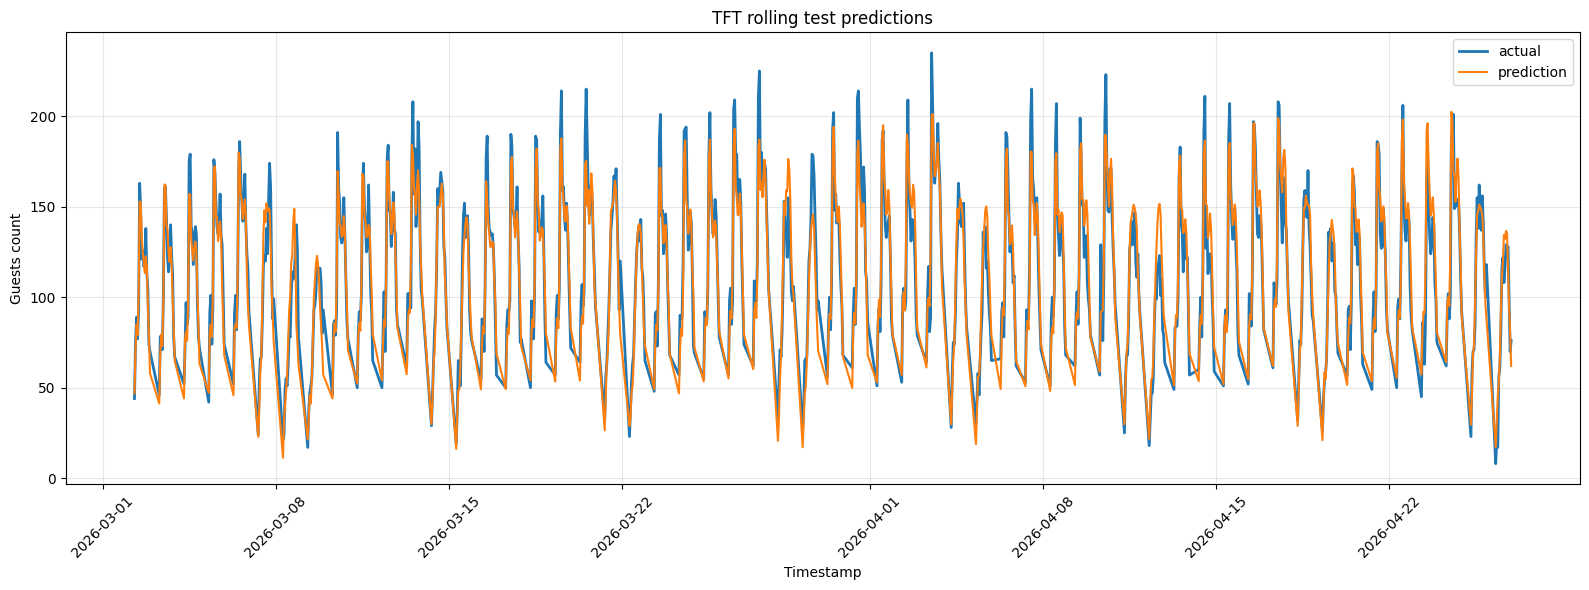

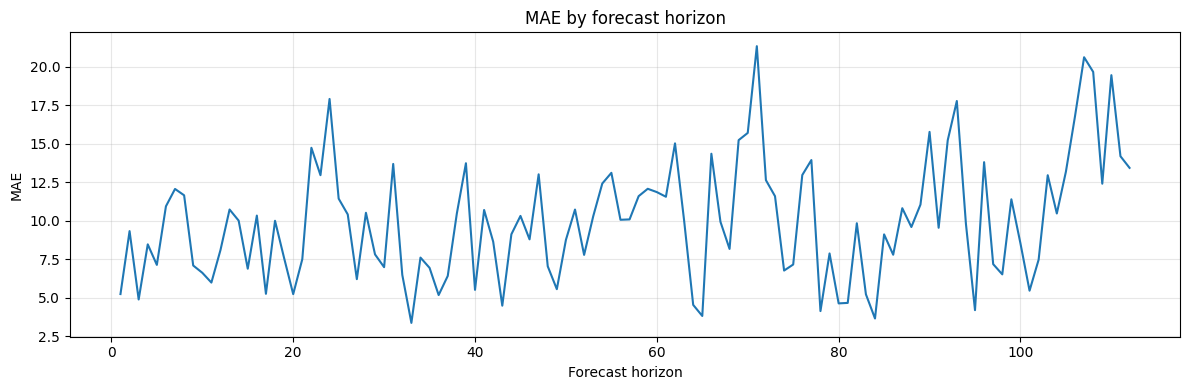

,timestamp,sale_date,sale_hour,actual,prediction,forecast_week_start,checkpoint_path,future_weather_source,weather_code_policy,error,abs_error,squared_error
0,2026-03-02 07:00:00,2026-03-02,7,44.0,46.967796,2026-03-02,checkpoints/present/tft_weather_model.ckpt,open_meteo_previous_runs_cached,api,2.967796,2.967796,8.807815
1,2026-03-02 08:00:00,2026-03-02,8,75.0,71.288544,2026-03-02,checkpoints/present/tft_weather_model.ckpt,open_meteo_previous_runs_cached,api,-3.711456,3.711456,13.774908
2,2026-03-02 09:00:00,2026-03-02,9,89.0,84.849861,2026-03-02,checkpoints/present/tft_weather_model.ckpt,open_meteo_previous_runs_cached,api,-4.150139,4.150139,17.223653
3,2026-03-02 10:00:00,2026-03-02,10,77.0,79.152580,2026-03-02,checkpoints/present/tft_weather_model.ckpt,open_meteo_previous_runs_cached,api,2.152580,2.152580,4.633602
4,2026-03-02 11:00:00,2026-03-02,11,93.0,101.406311,2026-03-02,checkpoints/present/tft_weather_model.ckpt,open_meteo_previous_runs_cached,api,8.406311,8.406311,70.666065
5,2026-03-02 12:00:00,2026-03-02,12,163.0,152.847672,2026-03-02,checkpoints/present/tft_weather_model.ckpt,open_meteo_previous_runs_cached,api,-10.152328,10.152328,103.069774
6,2026-03-02 13:00:00,2026-03-02,13,148.0,152.153473,2026-03-02,checkpoints/present/tft_weather_model.ckpt,open_meteo_previous_runs_cached,api,4.153473,4.153473,17.251337
7,2026-03-02 14:00:00,2026-03-02,14,121.0,133.917694,2026-03-02,checkpoints/present/tft_weather_model.ckpt,open_meteo_previous_runs_cached,api,12.917694,12.917694,166.866821
8,2026-03-02 15:00:00,2026-03-02,15,126.0,124.900131,2026-03-02,checkpoints/present/tft_weather_model.ckpt,open_meteo_previous_runs_cached,api,-1.099869,1.099869,1.209711
9,2026-03-02 16:00:00,2026-03-02,16,117.0,119.242554,2026-03-02,checkpoints/present/tft_weather_model.ckpt,open_meteo_previous_runs_cached,api,2.242554,2.242554,5.029047


,MAE,RMSE,WAPE_%,Bias,Directional_Accuracy_%,checkpoint_path,test_start,test_end,test_windows,max_test_weeks,future_weather_source,weather_code_policy
0,9.941,13.002,8.578,0.122,85.363,checkpoints/present/tft_weather_model.ckpt,2026-03-02,2026-04-26,8,8,open_meteo_previous_runs_cached,api


,MAE,RMSE,WAPE_%,Bias,Directional_Accuracy_%,forecast_week_start,rows
0,10.088,13.731,9.291,-2.495,86.486,2026-03-02,112
1,8.344,11.013,7.477,-2.039,86.486,2026-03-09,112
2,8.378,11.320,7.079,-3.760,85.586,2026-03-16,112
3,10.938,14.442,8.909,-5.148,88.288,2026-03-23,112
4,10.779,13.661,8.895,1.808,82.883,2026-03-30,112
5,11.130,14.610,9.715,3.187,81.982,2026-04-06,112
6,9.229,11.584,7.950,4.018,85.586,2026-04-13,112
7,10.645,13.098,9.334,5.405,85.586,2026-04-20,112


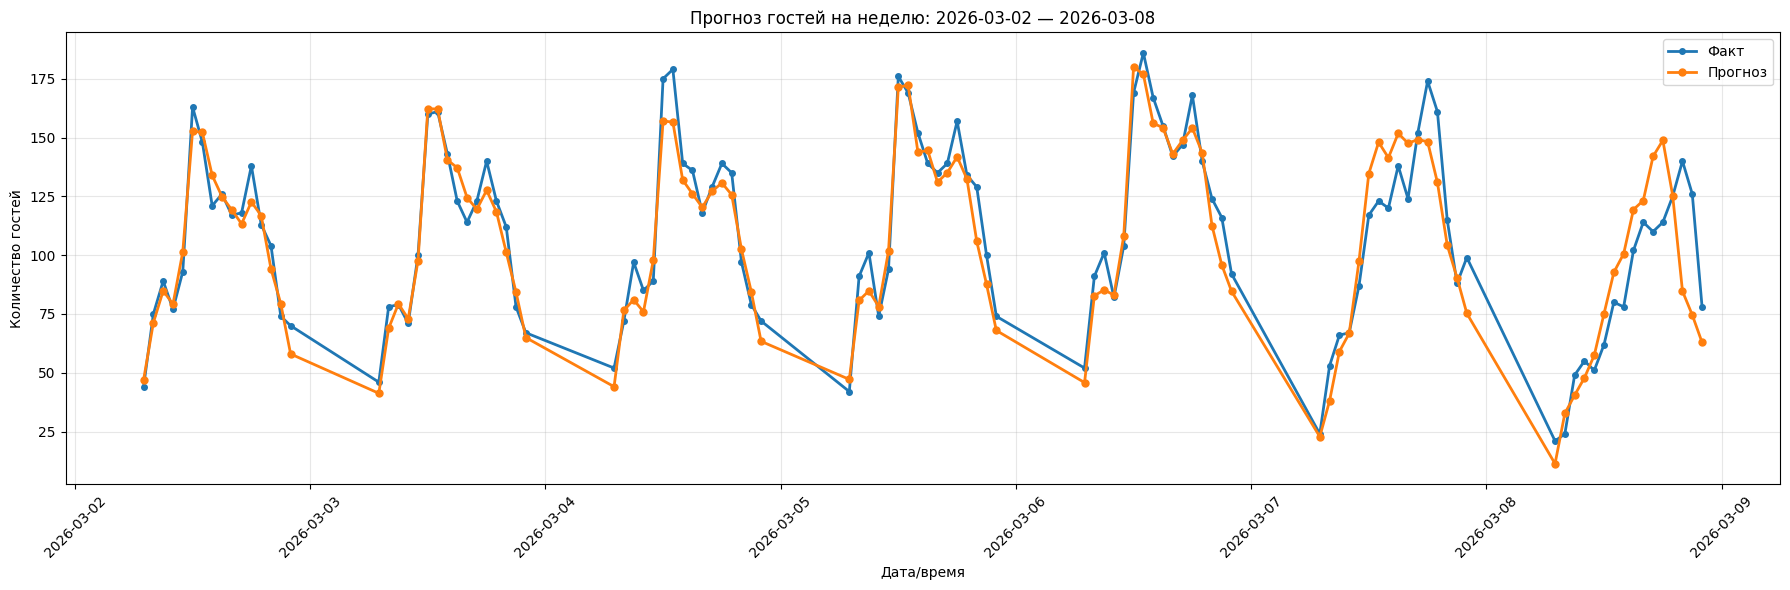

In [15]:

# ============================================================
# Plots and diagnostics
# ============================================================

plot_test_predictions(predictions_df)

display(predictions_df.head(30))
display(metrics_df)
display(weekly_metrics_df)


def plot_week_prediction(predictions_df, week_start=None, segment_id=None):
    df = predictions_df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    if "week_start" in df.columns:
        df["week_start"] = pd.to_datetime(df["week_start"])

    if week_start is None:
        if "week_start" in df.columns:
            week_start = df["week_start"].min()
        else:
            week_start = df["timestamp"].min().normalize()

    week_start = pd.Timestamp(week_start)
    week_end = week_start + pd.Timedelta(days=7)

    week_df = df[
        (df["timestamp"] >= week_start)
        & (df["timestamp"] < week_end)
    ].copy()

    if segment_id is not None and "segment_id" in week_df.columns:
        week_df = week_df[week_df["segment_id"] == segment_id].copy()

    actual_col_candidates = ["actual", "guests_count_original", "guests_count", "y_true", "target"]
    pred_col_candidates = ["prediction", "predicted", "y_pred", "predicted_guests_count", "p50", "median_prediction"]

    actual_col = next((c for c in actual_col_candidates if c in week_df.columns), None)
    pred_col = next((c for c in pred_col_candidates if c in week_df.columns), None)

    if actual_col is None:
        raise ValueError(f"Не нашёл колонку с фактом. Колонки: {list(week_df.columns)}")
    if pred_col is None:
        raise ValueError(f"Не нашёл колонку с прогнозом. Колонки: {list(week_df.columns)}")

    week_df = week_df.sort_values("timestamp")

    plt.figure(figsize=(18, 6))
    plt.plot(
        week_df["timestamp"], week_df[actual_col],
        label="Факт", linewidth=2, marker="o", markersize=4,
    )
    plt.plot(
        week_df["timestamp"], week_df[pred_col],
        label="Прогноз", linewidth=2, marker="o", markersize=5,
    )

    plt.title(f"Прогноз гостей на неделю: {week_start.date()} — {(week_end - pd.Timedelta(days=1)).date()}")
    plt.xlabel("Дата/время")
    plt.ylabel("Количество гостей")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return week_df


week_df = plot_week_prediction(predictions_df)


## 8. Fine-tune checkpoint

In [12]:

# ============================================================
# Fine-tune base checkpoint before Kaggle submission
# ============================================================
# Current best default from experiments:
#   base checkpoint -> recent fine-tune
#   start=2026-01-01, train_end=2026-04-27, epochs=4, lr=0.001
#
# Target week 2026-04-27..2026-05-03 is excluded.

FINE_TUNE_START = "2026-01-01"
FINE_TUNE_TRAIN_END = "2026-04-27"
FINE_TUNE_EPOCHS = 4
FINE_TUNE_LR = 0.001

BASE_CHECKPOINT_PATH = Path("checkpoints/present/tft_weather_model.ckpt")
# FINAL_CHECKPOINT_PATH = Path("checkpoints/present/tft_weather_model_recent_finetune_lr001_e4_20260427.ckpt")
# FINAL_METADATA_PATH = Path("checkpoints/present/tft_weather_model_recent_finetune_lr001_e4_20260427_metadata.json")

FINAL_CHECKPOINT_PATH = Path("checkpoints/present/tft_weather_model_recent_finetune-v3_20260427.ckpt") # Path("checkpoints/present/tft_weather_model_finetune_lr03_20260427.ckpt")
FINAL_METADATA_PATH = Path("checkpoints/present/tft_weather_model_recent_finetune_v3_20260427_metadata.json")

pl.seed_everything(config.seed, workers=True)

raw_df = load_raw_guests(CSV_PATH)

full_train_df, final_feature_config = build_training_frame(
    raw_df=raw_df,
    config=config,
    train_end=FINE_TUNE_TRAIN_END,
)

full_train_df["timestamp"] = pd.to_datetime(full_train_df["timestamp"])

fine_tune_df = full_train_df[
    (full_train_df["timestamp"] >= pd.Timestamp(FINE_TUNE_START))
    & (full_train_df["timestamp"] < pd.Timestamp(FINE_TUNE_TRAIN_END))
].copy()

fine_tune_df = fine_tune_df.sort_values("timestamp").reset_index(drop=True)

print("Fine-tune data:")
print("  range:", fine_tune_df["timestamp"].min(), "→", fine_tune_df["timestamp"].max())
print("  rows:", len(fine_tune_df))
print("  days:", fine_tune_df["sale_date"].nunique())
print("  base checkpoint:", BASE_CHECKPOINT_PATH)
print("  final checkpoint:", FINAL_CHECKPOINT_PATH)

min_required_rows = config.max_encoder_length + config.max_prediction_length
if len(fine_tune_df) < min_required_rows:
    raise ValueError(
        f"Too little fine-tune data: {len(fine_tune_df)} rows. "
        f"Need at least {min_required_rows}. Move FINE_TUNE_START earlier."
    )

target_rows = fine_tune_df[
    (fine_tune_df["timestamp"] >= pd.Timestamp("2026-04-27"))
    & (fine_tune_df["timestamp"] < pd.Timestamp("2026-05-04"))
]
if len(target_rows) > 0:
    raise ValueError("LEAKAGE: target submission week is present in fine_tune_df.")

model = TemporalFusionTransformer.load_from_checkpoint(str(BASE_CHECKPOINT_PATH))
model.hparams.learning_rate = FINE_TUNE_LR

required_cols = set(model.dataset_parameters["time_varying_known_reals"])
required_cols |= set(model.dataset_parameters["time_varying_known_categoricals"])
required_cols |= set(model.dataset_parameters["time_varying_unknown_reals"])
required_cols |= set(model.dataset_parameters["static_categoricals"])
required_cols |= set(model.dataset_parameters["static_reals"])
required_cols |= set(model.dataset_parameters["group_ids"])
required_cols.add(model.dataset_parameters["target"])
required_cols.add(model.dataset_parameters["time_idx"])

missing_cols = sorted(required_cols - set(fine_tune_df.columns))
if missing_cols:
    raise ValueError(f"Missing columns for fine-tune dataset: {missing_cols}")

fine_tune_dataset = TimeSeriesDataSet.from_parameters(
    model.dataset_parameters,
    fine_tune_df,
    predict=False,
    stop_randomization=False,
)

fine_tune_loader = fine_tune_dataset.to_dataloader(
    train=True,
    batch_size=config.batch_size,
    num_workers=getattr(config, "num_workers", 0),
)

trainer = pl.Trainer(
    max_epochs=FINE_TUNE_EPOCHS,
    accelerator=config.accelerator,
    devices=config.devices,
    gradient_clip_val=config.gradient_clip_val,
    callbacks=[LearningRateMonitor(logging_interval="epoch")],
    logger=TensorBoardLogger(config.log_dir, name="tft_recent_finetune_lr001_e4_20260427"),
    enable_checkpointing=False,
    log_every_n_steps=50,
)

trainer.fit(model, train_dataloaders=fine_tune_loader)

FINAL_CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
trainer.save_checkpoint(str(FINAL_CHECKPOINT_PATH))

fine_tune_metadata = {
    "checkpoint_path": str(FINAL_CHECKPOINT_PATH),
    "base_checkpoint_path": str(BASE_CHECKPOINT_PATH),
    "train_end": FINE_TUNE_TRAIN_END,
    "fine_tune_start": FINE_TUNE_START,
    "mode": "recent_period_fine_tune_for_final_submission",
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "fine_tune_learning_rate": FINE_TUNE_LR,
    "csv_path": str(CSV_PATH),
    "max_encoder_length": config.max_encoder_length,
    "max_prediction_length": config.max_prediction_length,
    "note": "Fine-tuned on observed data strictly before 2026-04-27. No target leakage from submission week.",
}

with open(FINAL_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(fine_tune_metadata, f, ensure_ascii=False, indent=2)

print("Saved fine-tuned checkpoint:", FINAL_CHECKPOINT_PATH)
print("Saved fine-tuned metadata:", FINAL_METADATA_PATH)


Seed set to 42
/tmp/ipykernel_5288/609167866.py:449: UserWarning: Could not download official production calendar for 2019: Unexpected isdayoff length for 2019: 1 vs 365. Using deterministic fallback based on weekends and fixed federal holidays.
  warnings.warn(


Training leakage audit
  train_end: 2026-04-27 00:00:00
  max train timestamp: 2026-04-26 22:00:00
  weather API range: 2019-01-02 00:00:00 .. 2026-04-26 00:00:00
  rows: 36864
Fine-tune data:
  range: 2026-01-01 07:00:00 → 2026-04-26 22:00:00
  rows: 1856
  days: 116
  base checkpoint: checkpoints/present/tft_weather_model.ckpt
  final checkpoint: checkpoints/present/tft_weather_model_recent_finetune-v3_20260427.ckpt


/home/jupyter/.local/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/jupyter/.local/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


TypeError: 'NoneType' object is not iterable

## 9. Future prediction helpers

In [10]:

# ============================================================
# Final prediction for 2026-04-27 — 2026-05-03
# Weather in decoder: Open-Meteo Previous Runs forecast-weather, cached locally
# Submission format: ID, guests_count
# ============================================================

SUBMISSION_START = pd.Timestamp("2026-04-27")
SUBMISSION_END = pd.Timestamp("2026-05-04")  # exclusive

FUTURE_OUTPUT_DIR = Path(config.output_dir) / "future_submission_previous_runs_old_checkpoint"
FUTURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_PATH = FUTURE_OUTPUT_DIR / "forecast_2026-04-27_2026-05-03_previous_runs_old_checkpoint.csv"
SUBMISSION_PATH = FUTURE_OUTPUT_DIR / "submission_2026-04-27_2026-05-03_previous_runs_old_checkpoint.csv"
PLOT_PATH = FUTURE_OUTPUT_DIR / "forecast_2026-04-27_2026-05-03_previous_runs_old_checkpoint.png"


def build_future_prediction_frame(
    raw_df: pd.DataFrame,
    config: TFTPipelineConfig,
    forecast_start: str | pd.Timestamp,
    prediction_periods: int | None = None,
) -> tuple[pd.DataFrame, TFTFeatureConfig, int, int]:
    """
    Build a future inference frame.

    Leakage contract:
      - encoder uses all real observed guests/weather strictly before forecast_start;
      - decoder target is hidden and replaced by a technical zero placeholder;
      - decoder weather is Open-Meteo Previous Runs forecast-weather from cache/API;
      - no actual target or actual archive weather from the predicted week is used.
    """

    if prediction_periods is None:
        prediction_periods = config.max_prediction_length

    forecast_start_ts = pd.Timestamp(forecast_start).normalize()

    observed = build_observed_calendar_frame(raw_df, config)
    history_all_segments = observed[observed["timestamp"] < forecast_start_ts].copy()

    if history_all_segments.empty:
        raise ValueError(f"No observed history before forecast_start={forecast_start_ts}.")

    history_all_segments = add_actual_weather_to_history(history_all_segments, config)

    last_segment_id = (
        history_all_segments
        .sort_values("timestamp")["segment_id"]
        .iloc[-1]
    )

    encoder_history = history_all_segments[
        history_all_segments["segment_id"] == last_segment_id
    ].copy()

    if len(encoder_history) < config.max_encoder_length:
        raise ValueError(
            f"Not enough encoder history. Got {len(encoder_history)}, "
            f"need at least {config.max_encoder_length}."
        )

    future = make_future_frame(
        forecast_start_ts,
        prediction_periods,
        config,
    )

    # The future week target must remain hidden.
    if "guests_count" in future.columns:
        future = future.drop(columns=["guests_count"])

    future["restaurant"] = "single_restaurant"
    future["segment_id"] = last_segment_id
    future["data_missing"] = 1

    # Kept only for schema consistency; not used in metrics here.
    future["guests_count_original"] = np.nan
    future["guests_count"] = np.nan

    future = add_calendar_features(future)
    future = add_holiday_features(future)

    # Important: this function is overridden in this notebook.
    # It uses Open-Meteo Previous Runs forecast-weather and caches API responses.
    future = fill_future_weather_from_history(history_all_segments, future)
    future = add_weather_derived_features(future)

    full_df = pd.concat(
        [encoder_history, future],
        ignore_index=True,
        sort=False,
    )

    full_df = full_df.sort_values("timestamp").reset_index(drop=True)
    full_df[config.time_idx] = np.arange(len(full_df), dtype=int)

    train_cutoff = int(
        full_df.loc[full_df["timestamp"] < forecast_start_ts, config.time_idx].max()
    )
    test_cutoff = int(full_df[config.time_idx].max())

    # Technical placeholder required by TimeSeriesDataSet.
    # This is not the true future target.
    full_df[config.target] = (
        pd.to_numeric(full_df[config.target], errors="coerce")
        .fillna(0.0)
    )

    feature_config = build_weather_feature_config(config)
    full_df = enforce_tft_dtypes(full_df, config, feature_config)
    check_tft_columns(full_df, config, feature_config)

    print("Future prediction frame")
    print("  forecast_start:", forecast_start_ts)
    print("  encoder max timestamp:", encoder_history["timestamp"].max())
    print("  decoder range:", future["timestamp"].min(), "→", future["timestamp"].max())
    print("  rows:", len(full_df))
    print("  future target source: hidden / NaN -> 0 placeholder")
    print("  future weather source: Open-Meteo Previous Runs cached forecast")

    return full_df, feature_config, train_cutoff, test_cutoff


def predict_future_week_with_checkpoint(
    csv_path: str | Path,
    checkpoint_path: str | Path,
    metadata_path: str | Path,
    forecast_start: str | pd.Timestamp,
    config: TFTPipelineConfig,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Predict one future 7-day week with a selected checkpoint.

    Uses training reference built at the old checkpoint's original train_end,
    while encoder history for the future prediction uses all observed data
    before forecast_start.
    """

    raw_df = load_raw_guests(csv_path)
    metadata = load_checkpoint_metadata(metadata_path)

    reference_train_end = metadata.get("train_end")
    if reference_train_end is None:
        raise ValueError(f"No train_end found in metadata: {metadata_path}")

    forecast_start_ts = pd.Timestamp(forecast_start).normalize()

    print("Checkpoint:", checkpoint_path)
    print("Metadata:", metadata_path)
    print("Reference train_end from checkpoint:", reference_train_end)
    print("Future forecast_start:", forecast_start_ts)

    # Warm actual historical weather cache only up to the day before forecast.
    warm_weather_cache(
        min_date=raw_df["sale_date"].min(),
        max_date=forecast_start_ts - pd.Timedelta(days=1),
        config=config,
    )

    # Warm forecast-weather cache for the decoder week.
    warm_previous_runs_weather_cache_for_week_starts([forecast_start_ts], config)

    # Build training reference matching the checkpoint encoders/scalers.
    reference_train_df, reference_feature_config = build_training_frame(
        raw_df=raw_df,
        config=config,
        train_end=reference_train_end,
    )

    training_reference, _ = make_training_dataset(
        reference_train_df,
        config,
        reference_feature_config,
    )

    model = TemporalFusionTransformer.load_from_checkpoint(str(checkpoint_path))
    model.eval()

    full_df, _, train_cutoff, test_cutoff = build_future_prediction_frame(
        raw_df=raw_df,
        config=config,
        forecast_start=forecast_start_ts,
        prediction_periods=config.max_prediction_length,
    )

    predict_loader = make_prediction_loader(
        training_reference=training_reference,
        full_df=full_df,
        config=config,
        train_cutoff=train_cutoff,
        test_cutoff=test_cutoff,
    )

    y_pred = model_predict_flat(
        model=model,
        predict_loader=predict_loader,
        config=config,
    )

    future_rows = (
        full_df[full_df[config.time_idx] > train_cutoff]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    if len(y_pred) != len(future_rows):
        raise ValueError(
            f"Prediction length mismatch. Got {len(y_pred)}, expected {len(future_rows)}."
        )

    forecast_df = future_rows[
        ["timestamp", "sale_date", "sale_hour"]
    ].copy()

    forecast_df["prediction"] = y_pred
    forecast_df["checkpoint_path"] = str(checkpoint_path)
    forecast_df["metadata_path"] = str(metadata_path)
    forecast_df["future_weather_source"] = "open_meteo_previous_runs_cached"
    forecast_df["weather_code_policy"] = PREVIOUS_RUNS_WEATHER_CODE_POLICY

    submission_df = forecast_df.copy()
    submission_df["ID"] = (
        pd.to_datetime(submission_df["timestamp"]).dt.strftime("%Y-%m-%d")
        + "-"
        + pd.to_datetime(submission_df["timestamp"]).dt.hour.astype(str).str.zfill(2)
    )

    submission_df["guests_count"] = (
        submission_df["prediction"]
        .clip(lower=0)
        .round()
        .astype(int)
    )

    submission_df = submission_df[["ID", "guests_count"]].copy()

    return forecast_df, submission_df




## 10. Predict final week and save Kaggle submission

Warming Open-Meteo Previous Runs forecast-weather cache...
  OK cached: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-04-27_2026-05-03_lead1to7.csv
Previous Runs forecast-weather cache is ready.
Checkpoint: checkpoints/present/tft_weather_model_recent_finetune-v3_20260427.ckpt
Metadata: checkpoints/present/tft_weather_model_recent_finetune_v3_20260427_metadata.json
Reference train_end from checkpoint: 2026-04-27
Future forecast_start: 2026-04-27 00:00:00
Weather cache ready: cache/weather/open_meteo_history_55p80185_37p53211_Europe_Moscow.csv
Warming Open-Meteo Previous Runs forecast-weather cache...
  OK cached: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-04-27_2026-05-03_lead1to7.csv
Previous Runs forecast-weather cache is ready.


/tmp/ipykernel_5288/609167866.py:449: UserWarning: Could not download official production calendar for 2019: Unexpected isdayoff length for 2019: 1 vs 365. Using deterministic fallback based on weekends and fixed federal holidays.
  warnings.warn(


Training leakage audit
  train_end: 2026-04-27 00:00:00
  max train timestamp: 2026-04-26 22:00:00
  weather API range: 2019-01-02 00:00:00 .. 2026-04-26 00:00:00
  rows: 36864


/home/jupyter/.local/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/jupyter/.local/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
/tmp/ipykernel_5288/609167866.py:449: UserWarning: Could not download official production calendar for 2019: Unexpected isdayoff length for 2019: 1 vs 365. Using deterministic fallback based on weekends and fixed federal holidays.
  warnings.warn(


Loaded forecast-weather cache: cache/weather_previous_runs/open_meteo_previous_runs_55p80185_37p53211_Europe_Moscow_2026-04-27_2026-05-03_lead1to7.csv


...

/home/jupyter/.local/lib/python3.10/site-packages/pytorch_forecasting/data/encoders.py:402: UserWarning: Found 1 unknown classes which were set to NaN
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
2026-05-11 23:07:36.220503: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-11 23:07:37.841709: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-11 23:07:41.032405: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

Saved forecast: outputs/future_submission_previous_runs_finetuned/forecast_2026-04-27_2026-05-03_previous_runs_finetuned.csv
Saved Kaggle submission: outputs/future_submission_previous_runs_finetuned/submission_2026-04-27_2026-05-03_previous_runs_finetuned.csv
Submission rows: 112
First ID: 2026-04-27-07
Last ID: 2026-05-03-22
Weather-code policy: api


,ID,guests_count
0,2026-04-27-07,57
1,2026-04-27-08,86
2,2026-04-27-09,88
3,2026-04-27-10,83
4,2026-04-27-11,107


,ID,guests_count
107,2026-05-03-18,123
108,2026-05-03-19,115
109,2026-05-03-20,94
110,2026-05-03-21,80
111,2026-05-03-22,79


count    112.000000
mean     106.392857
std       39.547977
min       20.000000
25%       82.750000
50%      105.500000
75%      130.000000
max      206.000000
Name: guests_count, dtype: float64

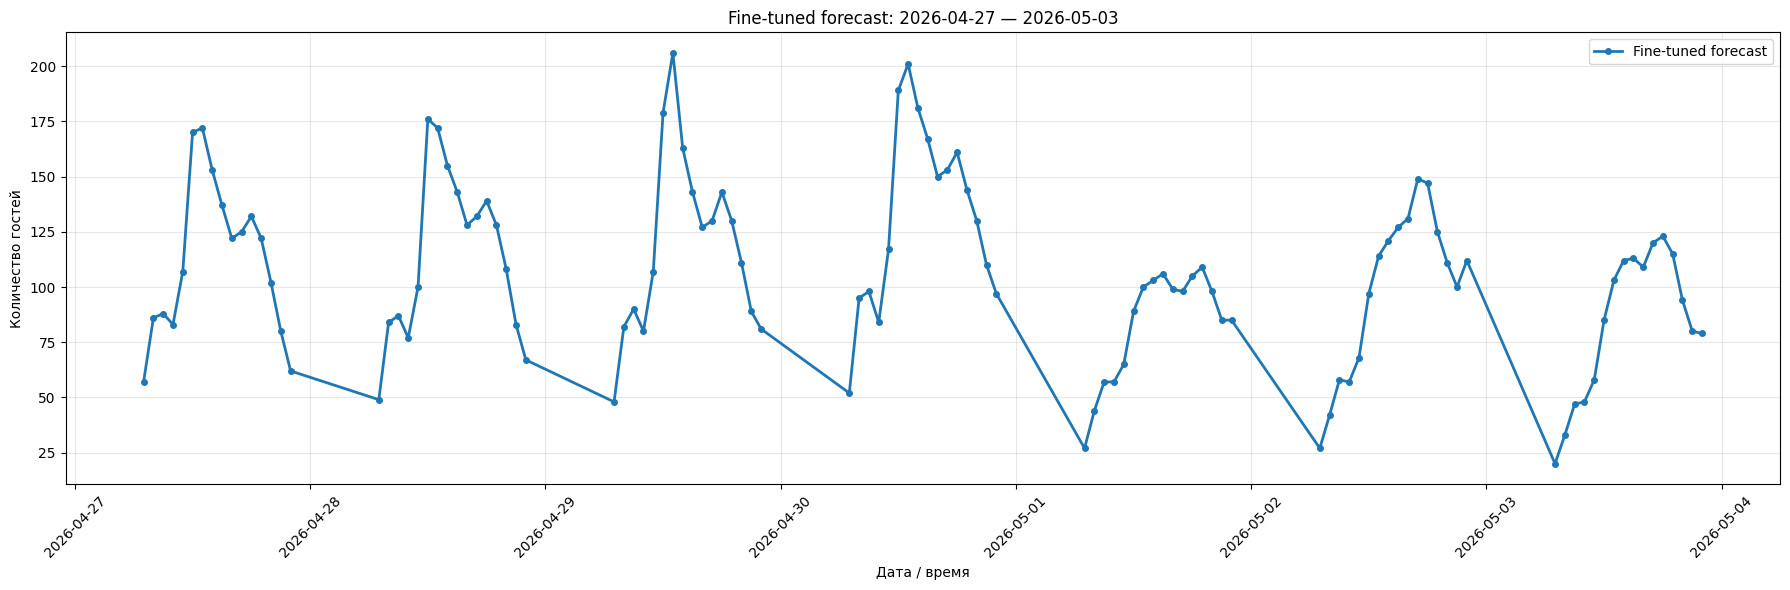

Saved plot: outputs/future_submission_previous_runs_finetuned/forecast_2026-04-27_2026-05-03_previous_runs_finetuned.png


In [13]:

# ============================================================
# Final prediction and Kaggle submission
# ============================================================

# Use fine-tuned checkpoint by default.
# To submit the base checkpoint instead, set these two paths back to BASE_CHECKPOINT_PATH / BASE_METADATA_PATH.
CHECKPOINT_PATH = FINAL_CHECKPOINT_PATH
METADATA_PATH = FINAL_METADATA_PATH

SUBMISSION_START = pd.Timestamp("2026-04-27")
SUBMISSION_END = pd.Timestamp("2026-05-04")  # exclusive

FUTURE_OUTPUT_DIR = Path(config.output_dir) / "future_submission_previous_runs_finetuned"
FUTURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_PATH = FUTURE_OUTPUT_DIR / "forecast_2026-04-27_2026-05-03_previous_runs_finetuned.csv"
SUBMISSION_PATH = FUTURE_OUTPUT_DIR / "submission_2026-04-27_2026-05-03_previous_runs_finetuned.csv"
PLOT_PATH = FUTURE_OUTPUT_DIR / "forecast_2026-04-27_2026-05-03_previous_runs_finetuned.png"

# Warm final-week forecast-weather cache before prediction.
warm_previous_runs_weather_cache_for_week_starts([SUBMISSION_START], config)

forecast_df, submission_df = predict_future_week_with_checkpoint(
    csv_path=CSV_PATH,
    checkpoint_path=CHECKPOINT_PATH,
    metadata_path=METADATA_PATH,
    forecast_start=SUBMISSION_START,
    config=config,
)

forecast_df["timestamp"] = pd.to_datetime(forecast_df["timestamp"])
forecast_df = forecast_df[
    (forecast_df["timestamp"] >= SUBMISSION_START)
    & (forecast_df["timestamp"] < SUBMISSION_END)
].copy()

expected_rows = config.max_prediction_length
if len(forecast_df) != expected_rows:
    raise ValueError(f"Expected {expected_rows} forecast rows, got {len(forecast_df)}.")
if len(submission_df) != expected_rows:
    raise ValueError(f"Expected {expected_rows} submission rows, got {len(submission_df)}.")

forecast_df.to_csv(FORECAST_PATH, index=False)
submission_df.to_csv(SUBMISSION_PATH, index=False)

print("Saved forecast:", FORECAST_PATH)
print("Saved Kaggle submission:", SUBMISSION_PATH)
print("Submission rows:", len(submission_df))
print("First ID:", submission_df["ID"].iloc[0])
print("Last ID:", submission_df["ID"].iloc[-1])
print("Weather-code policy:", PREVIOUS_RUNS_WEATHER_CODE_POLICY)

display(submission_df.head())
display(submission_df.tail())
display(submission_df["guests_count"].describe())

plt.figure(figsize=(18, 6))
plt.plot(
    forecast_df["timestamp"],
    forecast_df["prediction"].clip(lower=0).round(),
    label="Fine-tuned forecast",
    linewidth=2,
    marker="o",
    markersize=4,
)
plt.title("Fine-tuned forecast: 2026-04-27 — 2026-05-03")
plt.xlabel("Дата / время")
plt.ylabel("Количество гостей")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=160, bbox_inches="tight")
plt.show()

print("Saved plot:", PLOT_PATH)


## 11. Post processing

In [21]:

# ============================================================
# Optional May calibration
# ============================================================
# Uses historical actuals only; no 2026 target-week target leakage.
# Run after forecast_df is created.

CALIBRATION_YEARS = [2019, 2021, 2022, 2023, 2024, 2025]
TARGET_START = pd.Timestamp("2026-04-27")
TARGET_END = pd.Timestamp("2026-05-04")
CALIBRATION_STRENGTH = 0.22  # try 0.25, 0.50, 0.75

raw_df = load_raw_guests(CSV_PATH).copy()
raw_df["timestamp"] = pd.to_datetime(raw_df["timestamp"])
raw_df["sale_date"] = pd.to_datetime(raw_df["sale_date"])
raw_df["sale_hour"] = raw_df["timestamp"].dt.hour
raw_df["year"] = raw_df["sale_date"].dt.year
raw_df["mmdd"] = raw_df["sale_date"].dt.strftime("%m-%d")
raw_df["dow"] = raw_df["sale_date"].dt.dayofweek

hist = raw_df[raw_df["year"].isin(CALIBRATION_YEARS)].copy()

target_mmdd = ["04-27", "04-28", "04-29", "04-30", "05-01", "05-02", "05-03"]
hist_target = hist[hist["mmdd"].isin(target_mmdd)].copy()

spring = hist[
    (hist["mmdd"] >= "04-01")
    & (hist["mmdd"] <= "05-20")
    & (~hist["mmdd"].isin(target_mmdd))
].copy()

target_profile = (
    hist_target
    .groupby(["mmdd", "sale_hour"])["guests_count"]
    .mean()
    .reset_index(name="target_mean")
)

spring_profile = (
    spring
    .groupby(["dow", "sale_hour"])["guests_count"]
    .mean()
    .reset_index(name="spring_mean")
)

cal_df = forecast_df.copy()
cal_df["timestamp"] = pd.to_datetime(cal_df["timestamp"])
cal_df["sale_hour"] = cal_df["timestamp"].dt.hour
cal_df["mmdd"] = cal_df["timestamp"].dt.strftime("%m-%d")
cal_df["dow"] = cal_df["timestamp"].dt.dayofweek

cal_df = cal_df.merge(target_profile, on=["mmdd", "sale_hour"], how="left")
cal_df = cal_df.merge(spring_profile, on=["dow", "sale_hour"], how="left")

cal_df["raw_factor"] = cal_df["target_mean"] / cal_df["spring_mean"]
cal_df["raw_factor"] = cal_df["raw_factor"].replace([np.inf, -np.inf], np.nan).fillna(1.0)
cal_df["raw_factor"] = cal_df["raw_factor"].clip(0.75, 1.25)
cal_df["calibration_factor"] = 1.0 + CALIBRATION_STRENGTH * (cal_df["raw_factor"] - 1.0)
cal_df["prediction_calibrated"] = (cal_df["prediction"] * cal_df["calibration_factor"]).clip(lower=0)

display(cal_df[["timestamp", "prediction", "raw_factor", "calibration_factor", "prediction_calibrated"]].head(30))
print("Mean factor:", cal_df["calibration_factor"].mean())
print("Min/max factor:", cal_df["calibration_factor"].min(), cal_df["calibration_factor"].max())

CALIBRATED_SUBMISSION_PATH = (
    FUTURE_OUTPUT_DIR
    / f"submission_2026-04-27_2026-05-03_previous_runs_finetuned_may_calibrated_xd.csv"
)

cal_sub = cal_df.copy()
cal_sub["ID"] = (
    cal_sub["timestamp"].dt.strftime("%Y-%m-%d")
    + "-"
    + cal_sub["timestamp"].dt.hour.astype(str).str.zfill(2)
)
cal_sub["guests_count"] = cal_sub["prediction_calibrated"].round().astype(int)
cal_sub = cal_sub[["ID", "guests_count"]].copy()
cal_sub.to_csv(CALIBRATED_SUBMISSION_PATH, index=False)

print("Saved calibrated submission:", CALIBRATED_SUBMISSION_PATH)
display(cal_sub.head())
display(cal_sub.tail())


,timestamp,prediction,raw_factor,calibration_factor,prediction_calibrated
0,2026-04-27 07:00:00,57.230423,0.917721,0.981899,56.194470
1,2026-04-27 08:00:00,85.739182,0.879328,0.973452,83.462986
2,2026-04-27 09:00:00,88.034889,0.869391,0.971266,85.505290
3,2026-04-27 10:00:00,82.585831,0.913947,0.981068,81.022352
4,2026-04-27 11:00:00,107.113174,0.974408,0.994370,106.510092
5,2026-04-27 12:00:00,170.175049,0.915923,0.981503,167.027344
6,2026-04-27 13:00:00,172.441864,0.943981,0.987676,170.316669
7,2026-04-27 14:00:00,153.074615,0.982866,0.996231,152.497609
8,2026-04-27 15:00:00,137.148224,1.028876,1.006353,138.019479
9,2026-04-27 16:00:00,121.683548,1.005391,1.001186,121.827869


Mean factor: 0.9839946812874097
Min/max factor: 0.945 1.055
Saved calibrated submission: outputs/future_submission_previous_runs_finetuned/submission_2026-04-27_2026-05-03_previous_runs_finetuned_may_calibrated_xd.csv


,ID,guests_count
0,2026-04-27-07,56
1,2026-04-27-08,83
2,2026-04-27-09,86
3,2026-04-27-10,81
4,2026-04-27-11,107


,ID,guests_count
107,2026-05-03-18,122
108,2026-05-03-19,114
109,2026-05-03-20,95
110,2026-05-03-21,80
111,2026-05-03-22,82
